# 200_01 — Simulación y preprocesamiento · Escenario TAR (cambio de régimen por umbral sobre el rezago propio)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** genera los datos, toma la base de Fourier del generador como representación (**scores crudos, sin estandarizar**) y escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `200_03_convergencia` / `200_04_evaluacion` / `200_05_comparacion`

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento.



## 1. Imports y rutas

In [36]:
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioTAR, generar_escenario_TAR,
    guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap, plot_series_componentes,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [ ]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Variantes de la 200 (una por defecto). Se corre este notebook UNA VEZ POR VARIANTE.
VARIANTES = {
    # Chung §4.2 en escala cruda con gating mas libre (taupsij_z = 10, sd psi 0.32 en z).
    "chungEscG": {"hiperparametros": "chung_escala_cruda", "N": 30, "taupsij_z": 10.0},
    # Control opcional: el prior de psi del paper (taupsij_z = 100).
    "chungEsc":  {"hiperparametros": "chung_escala_cruda", "N": 30},
}
VARIANTE = "chungEscG"

VAR_CFG      = {"covariables": "propio", **VARIANTES[VARIANTE]}
CRUZADOS     = VAR_CFG["covariables"] == "cruzados"
BASENAME     = f"escenario_200_{VARIANTE}"
ESCENARIO_ID = 1      # escenario TAR (único)
REPLICA_ID   = 1      # réplica Monte Carlo
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

# Especificar componentes a estudiar 
M_FPCA_LIST = (1, 2, 3, 4, 5, 6, 7,8,9,10)

LIMPIAR_DIRECTORIOS = False

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # rezago propio: único M que se entrena (cruzados: todos)
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"VARIANTE        : {VARIANTE}  {VAR_CFG}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (se entrena solo M={M_ENTRENO})")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")


PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_200_chungEscG_1_r01
VARIANTE        : chungEscG  {'covariables': 'propio', 'hiperparametros': 'chung_escala_cruda', 'N': 30, 'taupsij_z': 10.0}
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   (se entrena solo M=10)
   M=1  ->  escenario_200_chungEscG_1_r01_m01
   M=2  ->  escenario_200_chungEscG_1_r01_m02
   M=3  ->  escenario_200_chungEscG_1_r01_m03
   M=4  ->  escenario_200_chungEscG_1_r01_m04
   M=5  ->  escenario_200_chungEscG_1_r01_m05
   M=6  ->  escenario_200_chungEscG_1_r01_m06
   M=7  ->  escenario_200_chungEscG_1_r01_m07
   M=8  ->  escenario_200_chungEscG_1_r01_m08
   M=9  ->  escenario_200_chungEscG_1_r01_m09
   M=10  ->  escenario_200_chungEscG_1_r01_m10


In [38]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_200_chungEscG_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_200_chungEscG_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_200_chungEscG_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_200_chungEscG_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_200_chungEscG_1_r01_m01
M=2  (escenario_200_chungEscG_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\s

### 2.1 `[CONFIG]` Parámetros del generador

`sim_escenario_TAR`: $X_t(\tau)=\mu(\tau)+\sum_{j=1}^{10}\xi_{tj}\varphi_j(\tau)$ con la base de Fourier y $\mu(\tau)=\sin(2\pi\tau)$ de la sección C. Cada score activo $j = 1..4$ sigue, en una coordenada cruda $u_j$, un AR(1) con dos regímenes asignados por **su propio rezago**:

$$P(R_{tj}=B\mid u_{j,t-1})=\Phi\!\left(\frac{u_{j,t-1}-c_j}{h_j}\right),\qquad u_{tj}=\mu_{R}+\phi_{R}\,u_{j,t-1}+s_{R}\,e_{tj}.$$

A es persistente y tranquilo, B revierte y es volátil; las componentes son independientes entre sí. $\xi_5..\xi_{10}$ son AR(1) propios con coeficiente 0.3. Parámetros y calibración: docstring de `pipelines/sim_escenario_TAR.py`. Regímenes, oráculo y soporte viven en `salida.internos`: **no** se entregan a la estimación.

In [39]:
# ── Parámetros fijos del estudio (comunes a los escenarios) ─────────────────
L_GRILLA   = 75     # puntos de la grilla
T_CURVAS   = 1000   # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.0    # sin ruido de medición: los scores son el insumo

SIM_CFG = ConfigEscenarioTAR(
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 300,         
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    # J, n_rezagos, lambda_1, rho: valores del módulo (sim_escenario_TAR.py)
    prop_train_referencia = PROP_TRAIN,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")


  L                       : 75
  T                       : 1000
  burn_in                 : 300
  sigma_obs               : 0.0
  R                       : 1
  seed                    : 41232
  media_fn                : media_seno
  jitter                  : 1e-10
  J                       : 10
  n_rezagos               : 2
  lambda_1                : 0.5
  rho                     : 0.55
  prop_train_referencia   : 0.7


### 2.2 Generación

In [40]:
salida = generar_escenario_TAR(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) = X_true: sigma_obs = 0, no hay ruido de medición
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — sólo referencia
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")


Observadas (1000, 75) · verdaderas (1000, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.0000   (nominal 0.0)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 1000
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = -0.0008933614892921632
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.0872636494156545
  var_puntual_min                  = 0.787730910756315
  var_puntual_max                  = 1.2735603021383204
  acf1_media                       = 0.24758359345180664
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = inf
  n_rezagos                        = 2
  ocupacion_regimen_B              = [0.416, 0.461, 0.414, 0.524]
  racha_media                      = [6.578947368421053, 4.424778761061948, 5.02959595959596, 4.23728813559322]
  r2_oraculo_por_componente        = [0.58863

In [41]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m03\escenario_1.npz
[raw · M=4] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m04\escenario_1.npz
[raw · M=5] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_1_r01_m05\escenario_1.npz
[raw · M=6] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_200_chungEscG_

### 2.3 Visualización de los datos

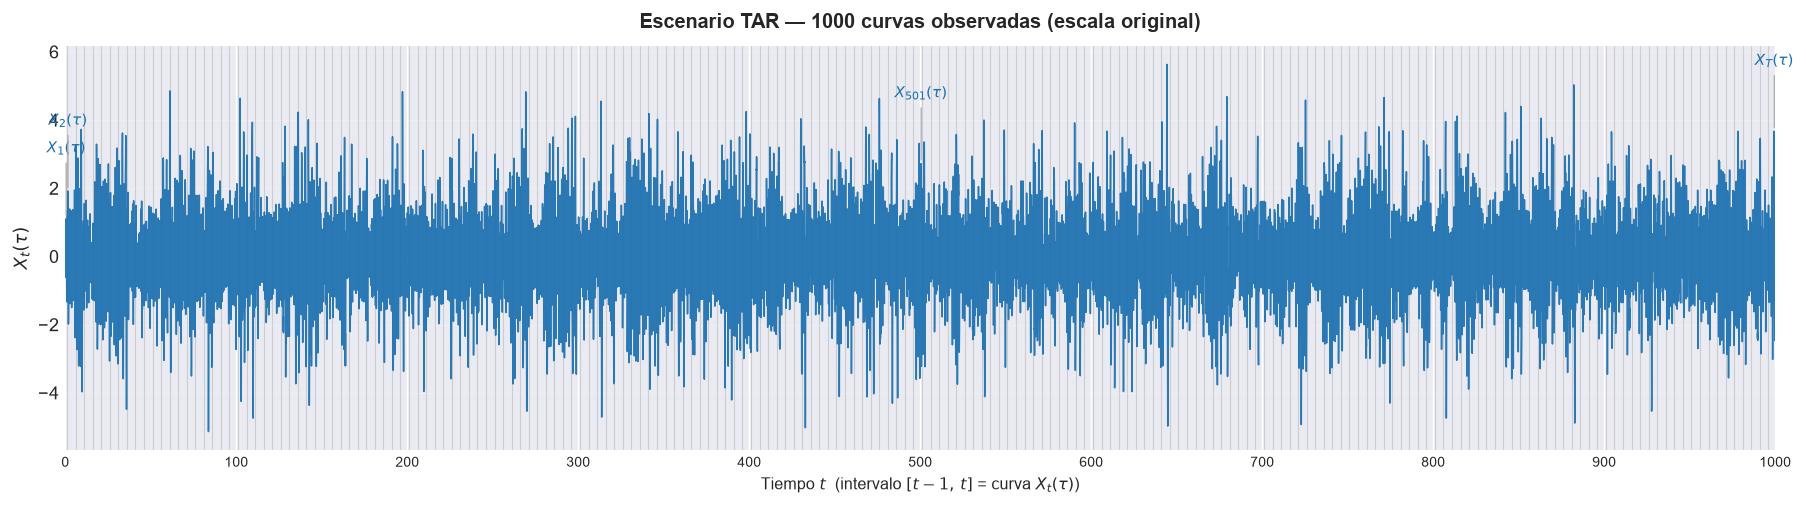

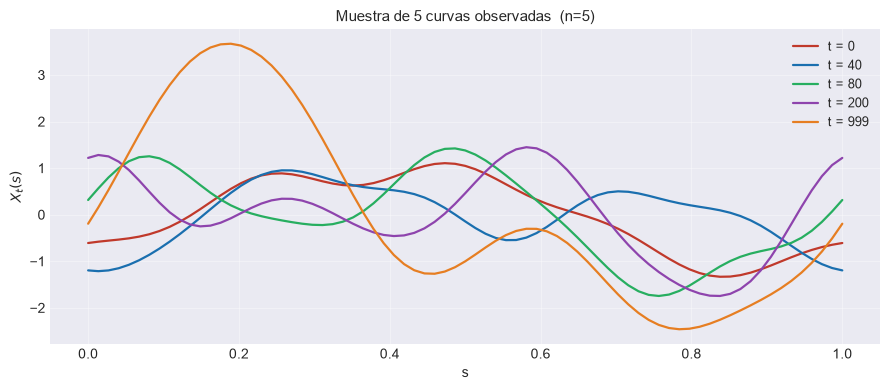

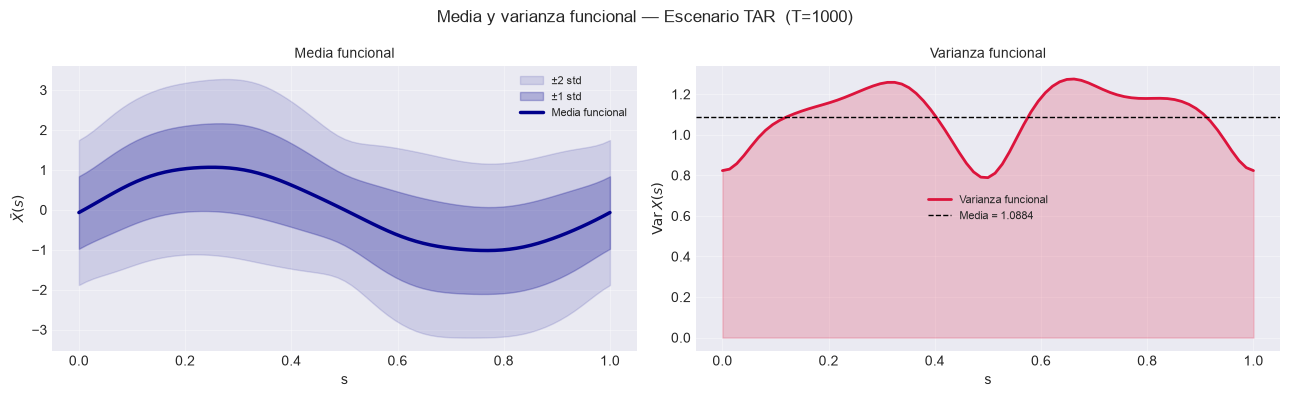

In [42]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario TAR — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario TAR")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

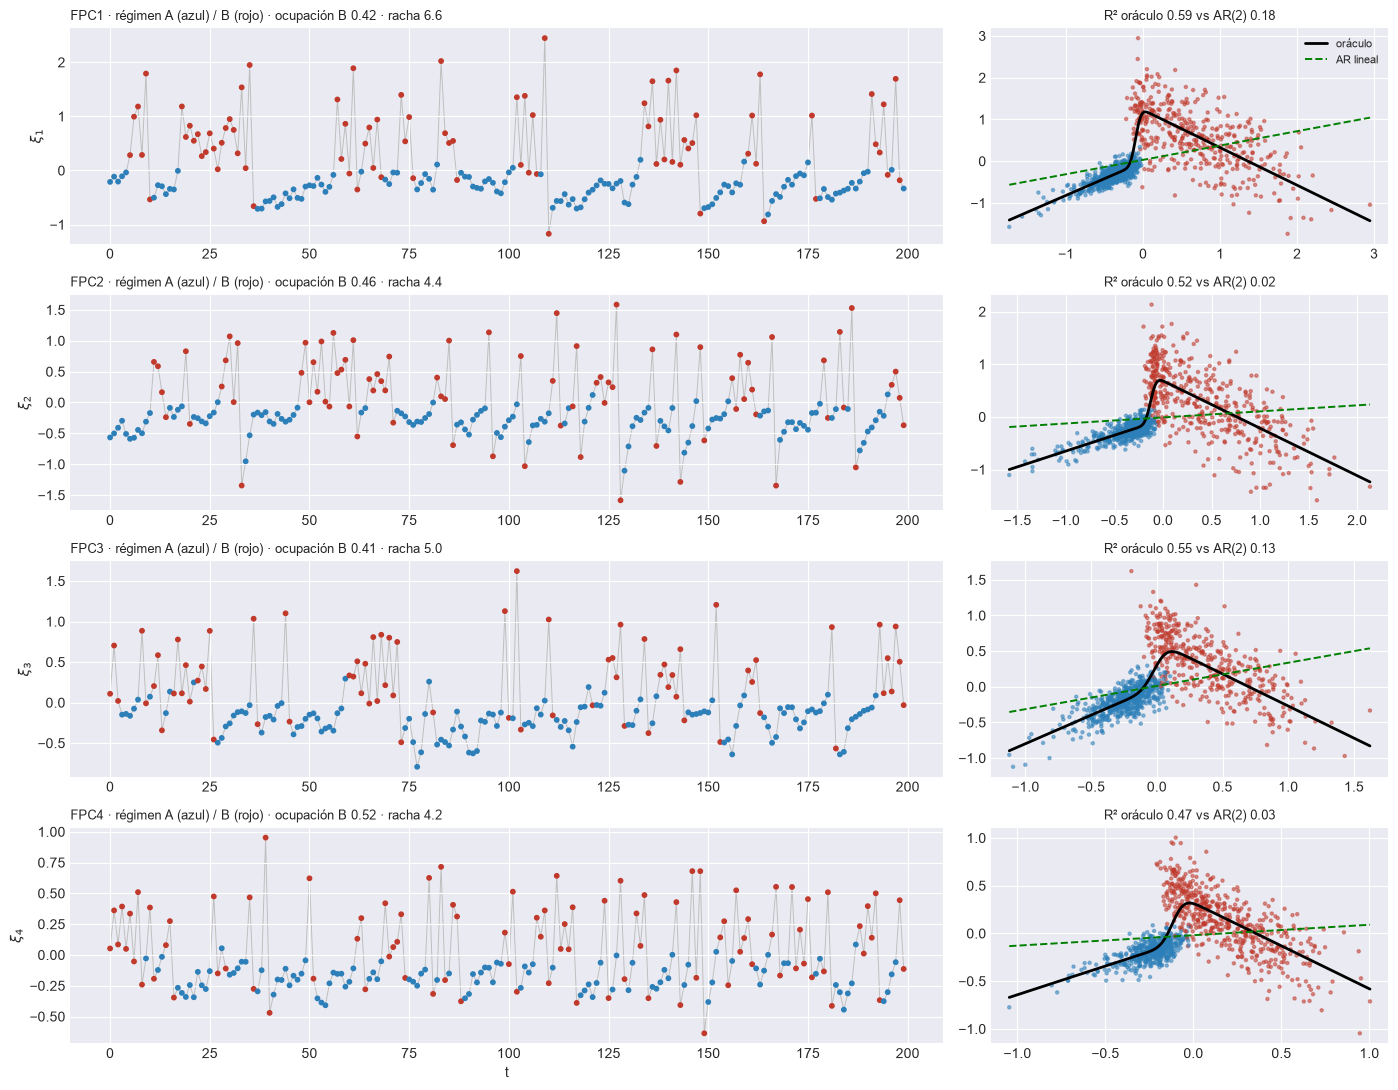

ocupación del régimen B      : [0.416 0.461 0.414 0.524]
racha media                  : [6.58 4.42 5.03 4.24]
R^2 L2 oráculo / lineal      : 0.5130 / 0.1272
R^2 oráculo    xi_1..5       : [0.589 0.525 0.553 0.471 0.091]
R^2 AR propio  xi_1..5       : [0.176 0.02  0.131 0.031 0.094]
var. entre regímenes / total : [0.113 0.101 0.127 0.179]
heterocedasticidad (q4/q1)   : [18.27 17.16  5.16  6.58]
|cos| ejes (scores verd.)    : [0.998 0.994 0.989 0.995 0.999 0.999]


In [43]:
# Regimen sorteado (no se entrega) y scores verdaderos xi (SON el insumo).
from scipy.stats import norm
from model_psbp_fd.pipelines.sim_escenario_TAR import PARAMETROS_TAR, MOMENTOS_TAR

REG     = salida.internos["regimen"][REPLICA_IDX]
XI_true = salida.internos["scores"][REPLICA_IDX]
_sc     = salida.internos["escala_scores"]
_d      = salida.diagnostico
_n      = 200

fig, axes = plt.subplots(4, 2, figsize=(14, 11), gridspec_kw={"width_ratios": [2.2, 1]})
for j in range(4):
    a, b = axes[j]
    a.plot(np.arange(_n), XI_true[:_n, j], color="0.75", lw=0.7, zorder=0)
    a.scatter(np.arange(_n), XI_true[:_n, j], s=10,
              c=np.where(REG[:_n, j] == 1, "#c0392b", "#2c7fb8"))
    a.set_ylabel(rf"$\xi_{j+1}$")
    a.set_title(f"FPC{j+1} · régimen A (azul) / B (rojo) · ocupación B "
                f"{_d['ocupacion_regimen_B'][j]:.2f} · racha {_d['racha_media'][j]:.1f}",
                fontsize=9, loc="left")
    x, y = XI_true[:-1, j], XI_true[1:, j]
    b.scatter(x, y, s=5, alpha=0.5, c=np.where(REG[1:, j] == 1, "#c0392b", "#2c7fb8"))
    g = np.linspace(x.min(), x.max(), 300)
    muA, phA, sA, muB, phB, sB, c, h = PARAMETROS_TAR[j]
    m_, d_ = MOMENTOS_TAR[j]
    u = g / _sc[j] * d_ + m_
    p = norm.cdf((u - c) / h)
    b.plot(g, ((1 - p) * (muA + phA * u) + p * (muB + phB * u) - m_) / d_ * _sc[j],
           "k", lw=2, label="oráculo")
    b.plot(g, np.polyval(np.polyfit(x, y, 1), g), "g--", lw=1.4, label="AR lineal")
    b.set_title(f"R² oráculo {_d['r2_oraculo_por_componente'][j]:.2f} vs AR(2) "
                f"{_d['r2_ar_propio_por_componente'][j]:.2f}", fontsize=9)
    if j == 0:
        b.legend(fontsize=8)
axes[-1, 0].set_xlabel("t")
fig.tight_layout()
replicar_figura("04b_mecanismo_scores.png", PATHS_POR_M, fig=fig)
plt.show()

print(f"ocupación del régimen B      : {np.round(_d['ocupacion_regimen_B'], 3)}")
print(f"racha media                  : {np.round(_d['racha_media'], 2)}")
print(f"R^2 L2 oráculo / lineal      : {_d['r2_oraculo']:.4f} / {_d['r2_lineal']:.4f}")
print(f"R^2 oráculo    xi_1..5       : {np.round(_d['r2_oraculo_por_componente'], 3)}")
print(f"R^2 AR propio  xi_1..5       : {np.round(_d['r2_ar_propio_por_componente'], 3)}")
print(f"var. entre regímenes / total : {np.round(_d['fraccion_varianza_entre_regimenes'], 3)}")
print(f"heterocedasticidad (q4/q1)   : {np.round(_d['heterocedasticidad_q4_q1'], 2)}")
print(f"|cos| ejes (scores verd.)    : {np.round(_d['cos_ejes_scores'][:6], 3)}")

### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [44]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 10 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 10 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 10 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —los autovalores de la FPCA y el
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [45]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 75)
prueba        : t ∈ [701, 1000]  → (300, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional: base de Fourier del generador

Los scores son el insumo de los modelos que los usan, y los coeficientes de la curva se proyectan con **todos** los scores: la base es la de Fourier del generador, ortonormal en $L^2$, de modo que $\theta_t=\mu_\theta+\xi_t$ y la Gram es la identidad. **No hay GCV, ni B-spline, ni FPCA estimada.**

### 3.1 Base conocida y coeficientes

`FunctionalRepresentation.desde_base` no ajusta nada: proyecta con la base del generador. Como $\mu(\tau)=\sin(2\pi\tau)=\varphi_1/\sqrt2$ cae en la base, la representación es **exacta** y el objetivo `curva_suavizada` coincide con la curva verdadera.

In [46]:
Phi_base = salida.internos["Phi"]                 # (G, J) Fourier del generador, ortonormal en L2
MU_THETA = salida.internos["mu_theta"]            # (J,) proyeccion de mu en la base

fr          = FunctionalRepresentation.desde_base(Phi_base, grilla)
THETA       = fr.transform(X, grilla)             # (T, K = J): mu_theta + xi
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)               # objetivo de evaluacion (docs 03_05_00)

assert np.allclose(THETA, MU_THETA + XI_true, atol=1e-10), "theta debe ser mu_theta + xi."
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"|Gram - I|_max               = {np.abs(fr.gram_ - np.eye(fr.K_)).max():.2e}")
print(f"max|theta - (mu_theta + xi)| = {np.abs(THETA - (MU_THETA + XI_true)).max():.2e}")
print(f"MISE(suavizada, verdadera)   = {float((((X_SUAV - X_true)**2).mean(1)).mean()):.2e}")

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "ninguno (base conocida)",
           "center": False, "n_basis": int(fr.K_), "order": None,
           "base": "fourier_generador"})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

THETA (1000, 10)  (train=700, test=300)
|Gram - I|_max               = 6.66e-16
max|theta - (mu_theta + xi)| = 1.33e-15
MISE(suavizada, verdadera)   = 2.43e-31
[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 10 directorios)


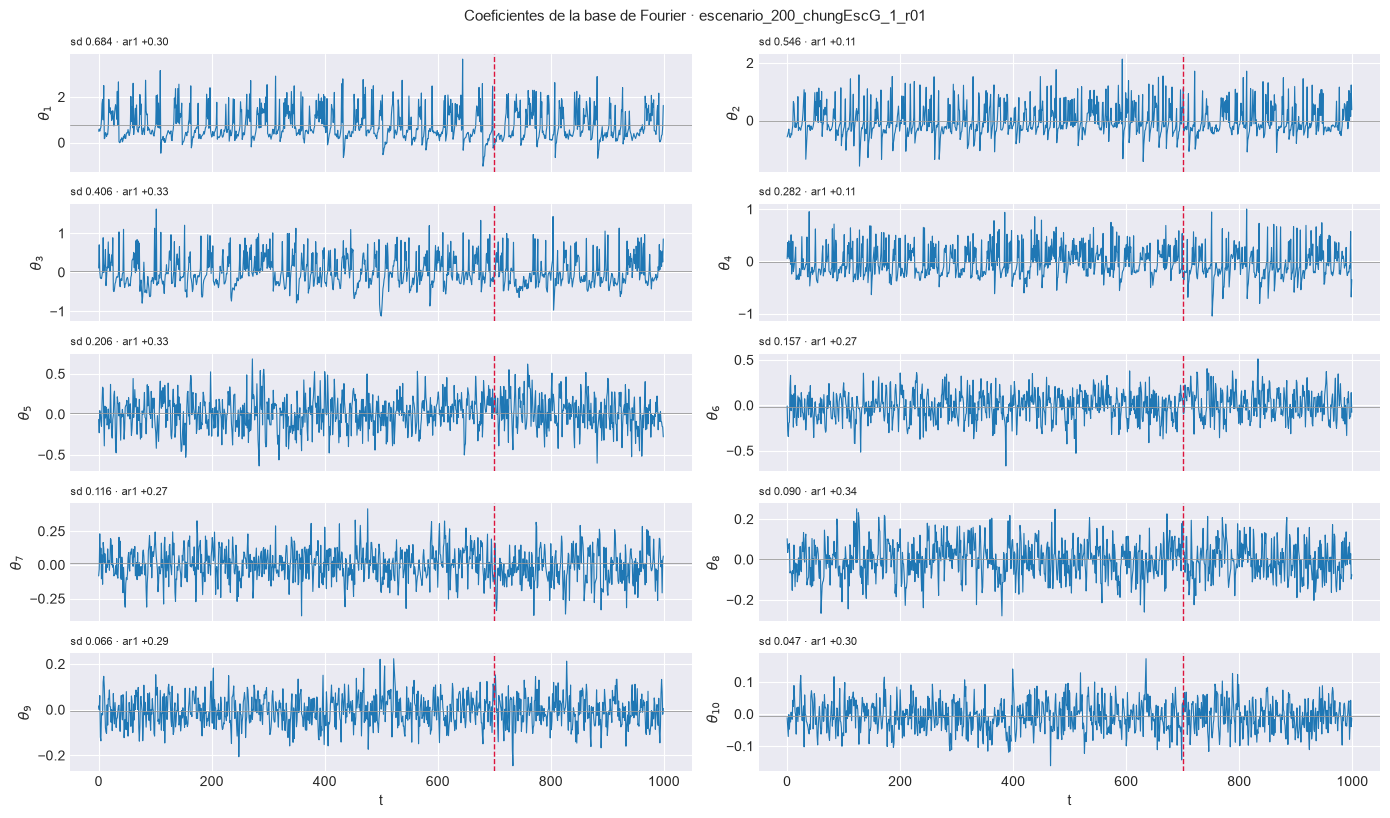

In [47]:
# Un panel por coeficiente theta_j = mu_theta + xi_j (la media funcional solo corre el nivel de theta_1).
fig = plot_series_componentes(
    THETA, T0=T0, simbolo=r"\theta",
    titulo=f"Coeficientes de la base de Fourier · {EXPERIMENT_BASE}")
replicar_figura("06_series_coeficientes.png", PATHS_POR_M, fig=fig)
plt.show()

### 3.2 FPCA de oráculo

La FPCA **no estima**: sus autofunciones son las $\varphi_j$ y sus scores los $\xi_{tj}$ del generador, en el orden de la base. Sólo los autovalores (varianza de cada score) se calculan con el bloque de entrenamiento. $K=J=10$ acota el barrido en $M$.

In [48]:
K = Phi_base.shape[1]
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede K = J = {K} scores del generador.")

fpca = FPCA_L2.desde_scores_conocidos(
    Phi_base, grilla, MU_THETA, XI_true[idx_train].var(axis=0, ddof=1), n_ajuste=T0)

_ver = fpca.verificar(fr=fr)      # identidades estructurales (sin THETA_train: no hubo ajuste)
print("Verificación FPCA de oráculo:")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")
assert _ver["todo_ok"], "Las identidades estructurales de la FPCA de oráculo no se cumplen."

fpca.set_M(K)
assert np.allclose(fpca.transform(THETA), XI_true, atol=1e-10), "los scores deben ser xi."

VAR_TARGET = 0.95
M_SUGERIDO = fpca.seleccionar_M(VAR_TARGET)
print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
for _M in M_FPCA_LIST:
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}"
          + ("  ·  regla del 95 %" if _M == M_SUGERIDO else ""))

Verificación FPCA de oráculo:
  M                                  = 10
  K                                  = 10
  n_ajuste                           = 700
  cond_W                             = 1.000e+00
  err_ortonormalidad_L2              = 1.221e-15
  err_ortonormalidad_gram            = 1.665e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_linealidad_reconstruct_rel']
  todo_ok                            = True

K disponibles: 10   ·   sugerencia (var ≥ 95%): M = 5
  M=1: var. acum = 42.3063%
  M=2: var. acum = 69.2705%
  M=3: var. acum = 84.2086%
  M=4: var. acum = 91.4081%
  M=5: var. acum = 95.2358%  ·  regla del 95 %
  M=6: var. acum = 97.4576%
  M=7: var. acum = 98.6746%
  M=8: var. acum = 99.4035%
  M=

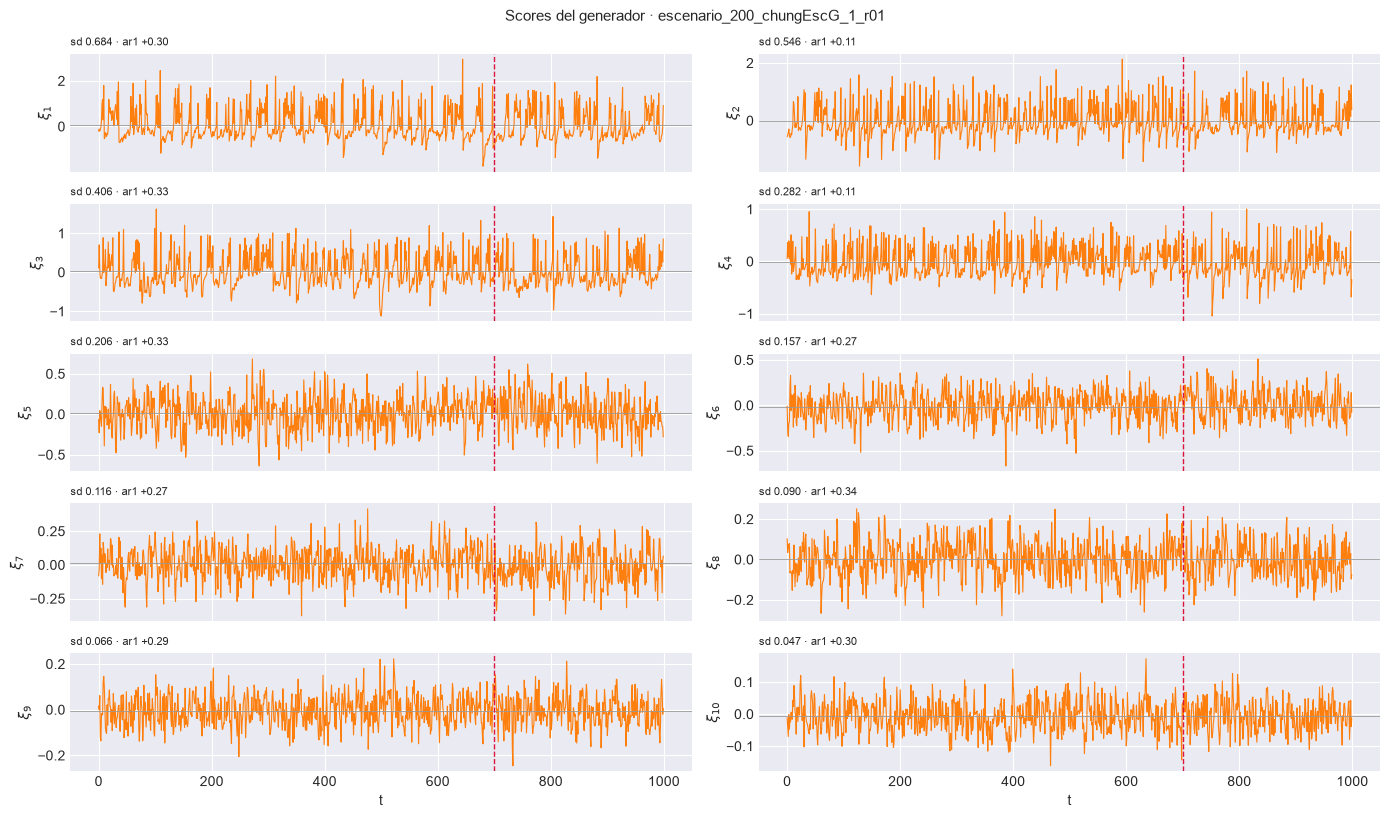

In [49]:
# Un panel por score xi_j, los J = K del generador (los que alimentan al modelo).
XI = fpca.transform(THETA)                       # (T, K), fpca con M = K
fig = plot_series_componentes(
    XI, T0=T0, simbolo=r"\xi", color="C1",
    titulo=f"Scores del generador · {EXPERIMENT_BASE}")
replicar_figura("07b_series_scores.png", PATHS_POR_M, fig=fig)
plt.show()

## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA
- §4.3: diagnóstico de rezagos (Pearson y Spearman) sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [50]:
def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3 —`fpca`,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) = xi del generador, primeras M
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train y se registra n_ajuste igual, porque verificar_contrato
    # exige n_ajuste == T0. Lo que NO se hace es aplicarlo: ver abajo.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    # SIN ESTANDARIZAR MATLAB recibe los scores en su ESCALA PROPIA. El objeto
    # no se elimina
    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------

    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]
    # Rezago PROPIO: la componente k solo ve xi_(k,t-1..t-N_LAGS). CRUZADOS: ve
    # todos los rezagos de todas (p = M*N_LAGS). cov_names (union, lag-mayor) lo
    # usa el _05 para RF/GBT.
    if CRUZADOS:
        cov_por_comp = {k: list(cov_names) for k in range(n_components)}
    else:
        cov_por_comp = {k: [f"fpc_{COMPONENT_IDX[k] + 1}_lag{lag}"
                            for lag in range(1, N_LAGS + 1)]
                        for k in range(n_components)}
    COVARIABLES = "todos_los_rezagos" if CRUZADOS else "rezago_propio"

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_por_comp[0])} covariable(s) por componente ({COVARIABLES})")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = (np.hstack([SCORES_sel[t_idx - lag, :] for lag in range(1, N_LAGS + 1)])
                  if CRUZADOS else
                  np.column_stack([SCORES_sel[t_idx - lag, k] for lag in range(1, N_LAGS + 1)]))
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_por_comp[k])

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "cov_por_componente": {str(k): cov_por_comp[k] for k in range(n_components)},
        "covariables":   COVARIABLES,
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- §4.5 Hiperparametros y MCMC -----------------------------------------
    # Chung §4.2 en escala cruda, con las sd de TRAIN: btau y taupsij escalan con
    # la varianza de cada componente; mupsij = 0. El tipo sale del nombre
    # fpc_<idx>_lag<l>: rezago propio o cruzado, y su lag.
    def _clasificar(nombre, k_modelo):
        assert nombre in cov_por_comp[k_modelo], (
            f"{nombre} no es covariable de la componente {k_modelo}.")
        idx, lag = nombre[len("fpc_"):].split("_lag")
        propio = int(idx) == COMPONENT_IDX[k_modelo] + 1
        return f"{'own' if propio else 'cross'}_lag{int(lag)}"

    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        sd_y = float(SCORES_train[:, k].std(ddof=0))
        sd_x = dfs_train[k][cov_por_comp[k]].to_numpy().std(axis=0, ddof=0)
        _ab  = [_beta_pi(nm, k) for nm in cov_por_comp[k]]
        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "btau":    HP_CHUNG_ESC["btau_z"] * sd_y ** 2,
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.zeros(len(cov_por_comp[k])),
            "taupsij": HP_CHUNG_ESC["taupsij_z"] * sd_x ** 2})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    print(f"  {'k':>2} {'fpc':>4} {'var(y)':>9} {'E[tau]':>8} {'btau':>9}  taupsij")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {SCORES_train[:, k].var(ddof=0):>9.5f} "
              f"{hp['atau']/hp['btau']:>8.2f} {hp['btau']:>9.5f}  "
              f"{np.array2string(hp['taupsij'], precision=3)}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "variante":     {"nombre": VARIANTE, **VAR_CFG,
                         "grid_gamma": "por_predictor_rango_train_con_extremos",
                         **({"chung_escala_cruda": {**HP_CHUNG_ESC,
                             "ab_por_lag": {str(l): v for l, v in HP_CHUNG_ESC["ab_por_lag"].items()}}}
                            if VAR_CFG["hiperparametros"] == "chung_escala_cruda" else {})},
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "m_entrenamiento": int(M if CRUZADOS else M_ENTRENO),
        "trazas_en":    experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID,
                                      M if CRUZADOS else M_ENTRENO),
        "covariables":  COVARIABLES,
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        # Contra QUE se mide el error (docs 03_05_00). Ninguno es la grilla cruda.
        #   principal  : curva suavizada = representacion B-spline de la observada
        #   secundario : X_t^(M), la expansion truncada; solo metodos sobre scores
        "objetivo_evaluacion": "curva_suavizada",
        "objetivo_secundario": "representacion_fpca",
        # Forzado por el modelo, no es perilla: la variabilidad vive en la mezcla.
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [20, 30, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_SUAV, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva SUAVIZADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_por_comp[0])),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

VARIANTE 'chungEscG': HP_GLOBAL={'atau': 0.5, 'btau': 0.5, 'ag': 0.5, 'bg': 0.5, 'mumu': 0.0, 'taumu': 1.0, 'pwj': 0.5}
  own_lag1: apij=0.5, bpij=0.5  E[pi]=0.500
  own_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
  own_lag3: apij=0.5, bpij=5.0  E[pi]=0.091
  own_lag4: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag1: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag2: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag3: apij=0.5, bpij=5.0  E[pi]=0.091
  cross_lag4: apij=0.5, bpij=5.0  E[pi]=0.091
N=30  ·  mupsij=0, taupsij=10*sd_x^2, btau=0.5*sd_y^2 (Chung en escala cruda)

M = 1   ·   escenario_200_chungEscG_1_r01_m01
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 1   <- DIFIERE de la regla: es un punto de sensibilidad
M = 1   var. explicada = 42.3063%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.043
[test]  var xi / lambda = [0.946]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


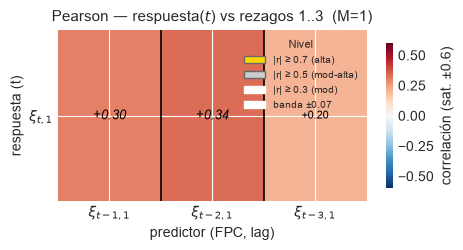

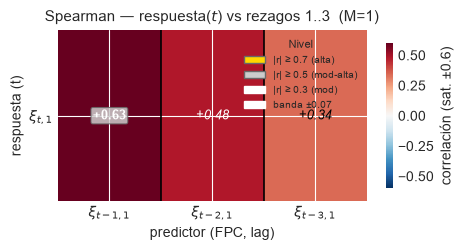

componentes : 1 -> índices [0]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 3 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      btau  taupsij
   0    1   0.46743     2.14   0.23372  [4.687 4.674 4.632 4.633]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_200_chungEscG_1_r01_m01
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,300.0000,0.6659,0.6659,-0.0041,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6992,-0.1073,1.1058,1.0515


contrato_ok = True   (M=1, K=10, T0=700, n_components=1)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_200_chungEscG_1_r01_m02
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 69.2705%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.043
[test]  var xi / lambda = [0.946 0.89 ]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


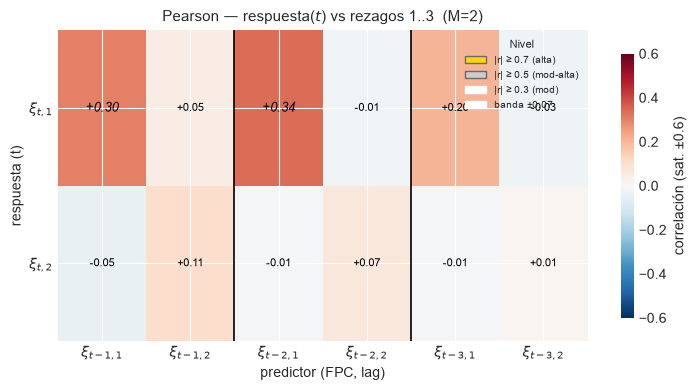

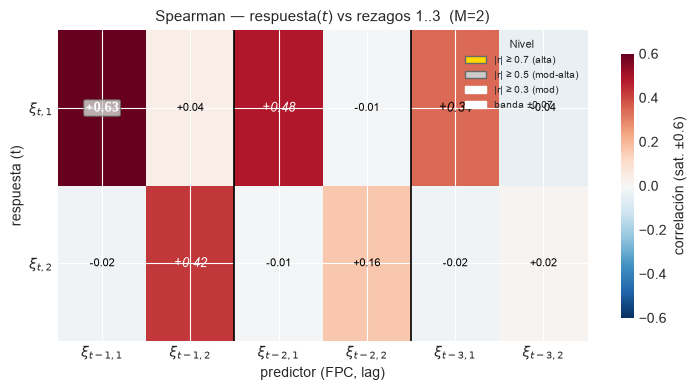

componentes : 2 -> índices [0, 1]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_1_lag4', 'fpc_2_lag4']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 6 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      btau  taupsij
   0    1   0.46743     2.14   0.23372  [4.687 4.674 4.632 4.633]
   1    2   0.29792     3.36   0.14896  [2.983 2.985 2.988 2.976]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_200_chungEscG_1_r01_m02
[out_artefact] eval_config.json


,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.5902,-0.0021,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.6892,-0.4251,1.3024,1.1412


contrato_ok = True   (M=2, K=10, T0=700, n_components=2)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_200_chungEscG_1_r01_m03
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 84.2086%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.043
[test]  var xi / lambda = [0.946 0.89  0.912]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


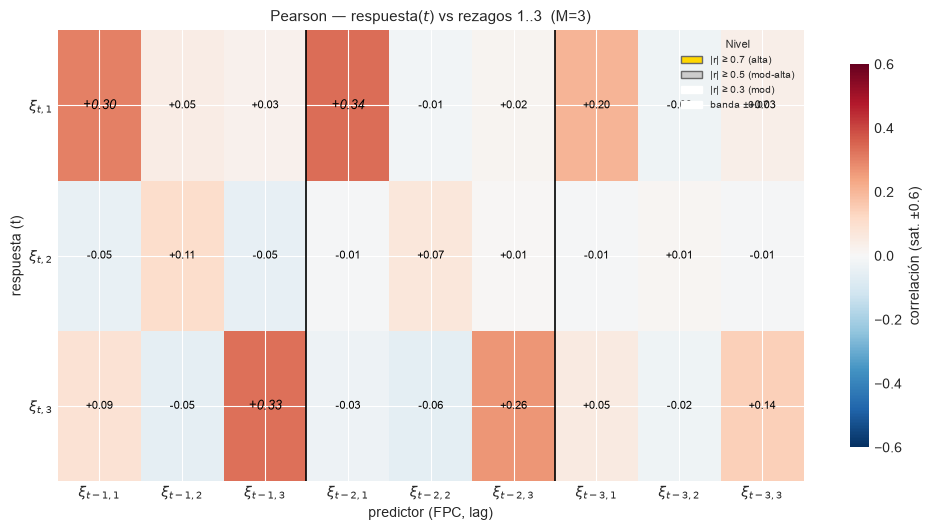

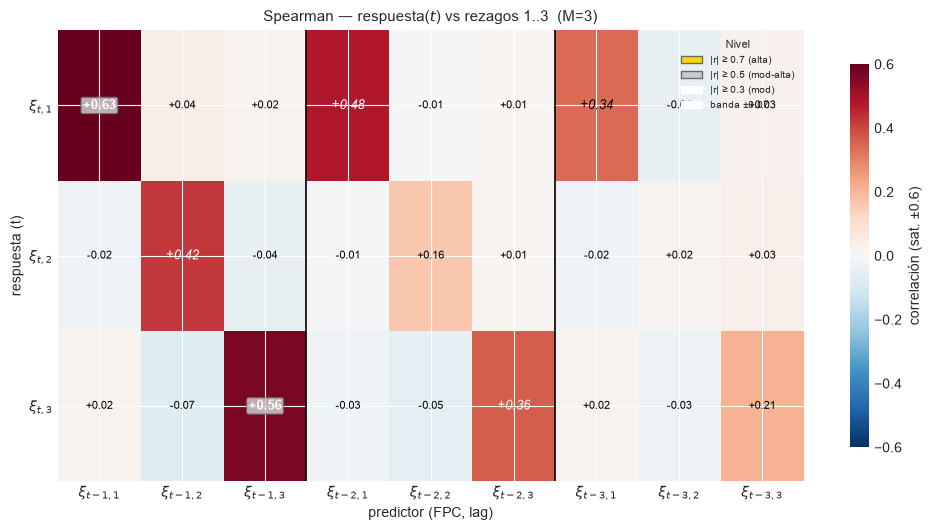

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 9 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      btau  taupsij
   0    1   0.46743     2.14   0.23372  [4.687 4.674 4.632 4.633]
   1    2   0.29792     3.36   0.14896  [2.983 2.985 2.988 2.976]
   2    3   0.16505     6.06   0.08252  [1.653 1.652 1.658 1.657]
[out_artefact] hyperparameters.json -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_200_chungEscG_1_r01_m03
[out_artefact] eval_config.json

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.5227,-0.0015,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.6110,-0.4082,1.3586,1.1656


contrato_ok = True   (M=3, K=10, T0=700, n_components=3)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 4   ·   escenario_200_chungEscG_1_r01_m04
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 4   <- DIFIERE de la regla: es un punto de sensibilidad
M = 4   var. explicada = 91.4081%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


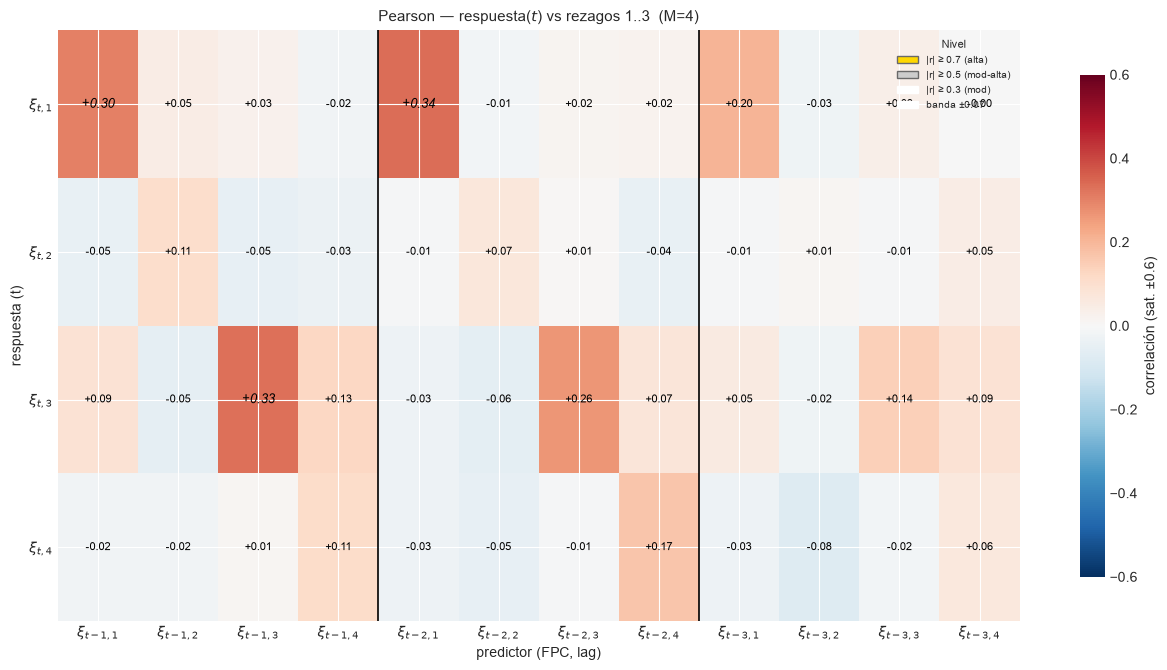

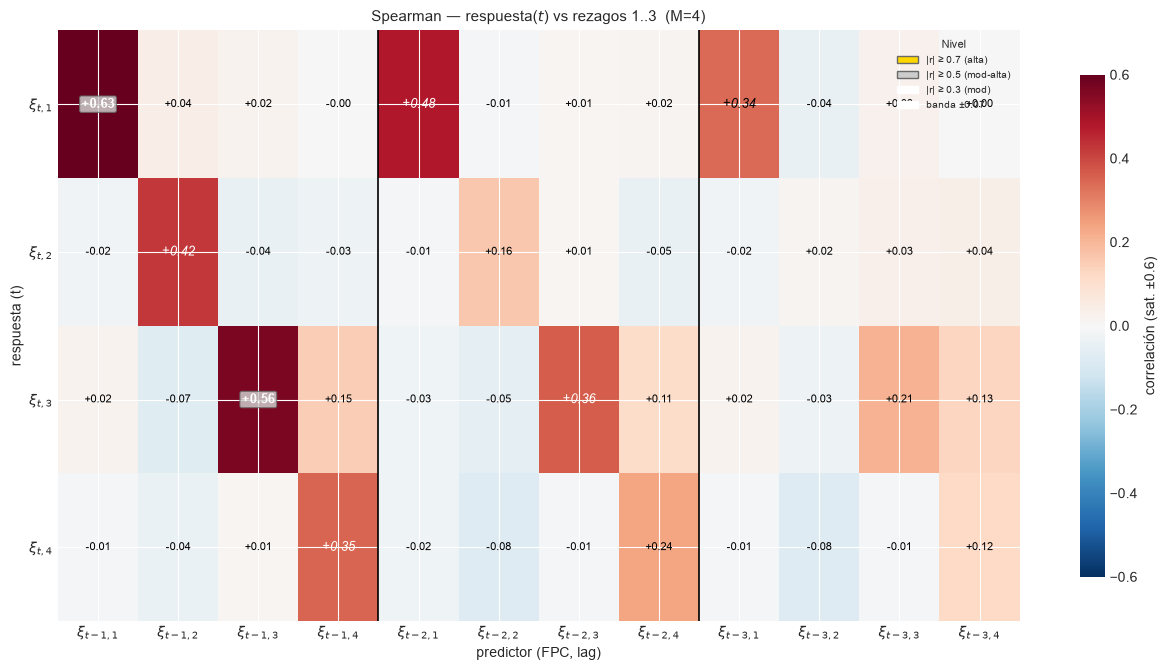

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4']
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 12 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      btau  taupsij
   0    1   0.46743     2.14   0.23372  [4.687 4.674 4.632 4.633]
   1    2   0.29792     3.36   0.14896  [2.983 2.985 2.988 2.976]
   2    3   0.16505     6.06   0.08252  [1.653 1.652 1.658 1.657]
   3    4   0.07954    12.57   0.03977  [0.794 0.794 0.795 0.795]
[out_artefact] hyper

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.4710,-0.0105,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.5633,-0.5156,1.4355,1.1981


contrato_ok = True   (M=4, K=10, T0=700, n_components=4)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 5   ·   escenario_200_chungEscG_1_r01_m05
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 5   (coincide con la regla)
M = 5   var. explicada = 95.2358%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211 1.068]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


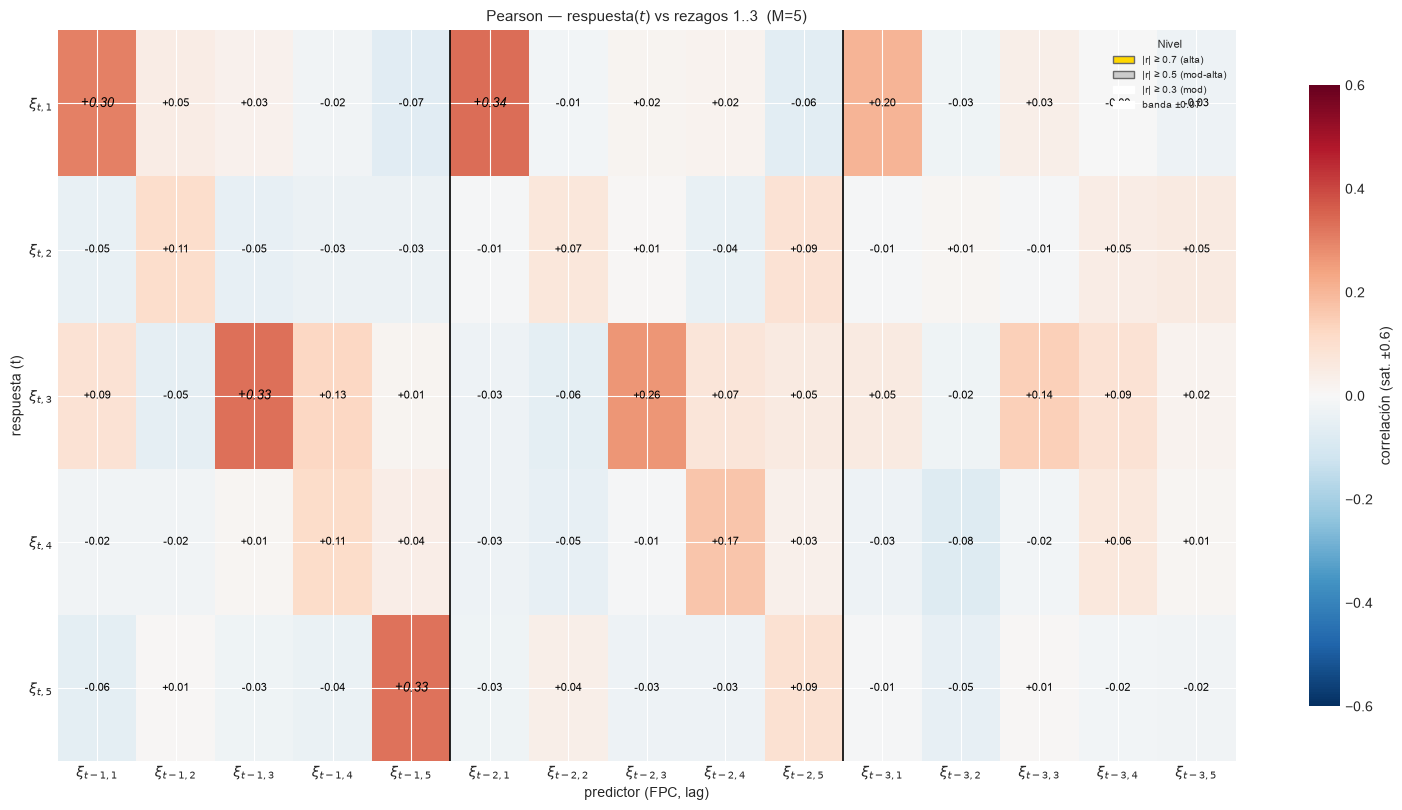

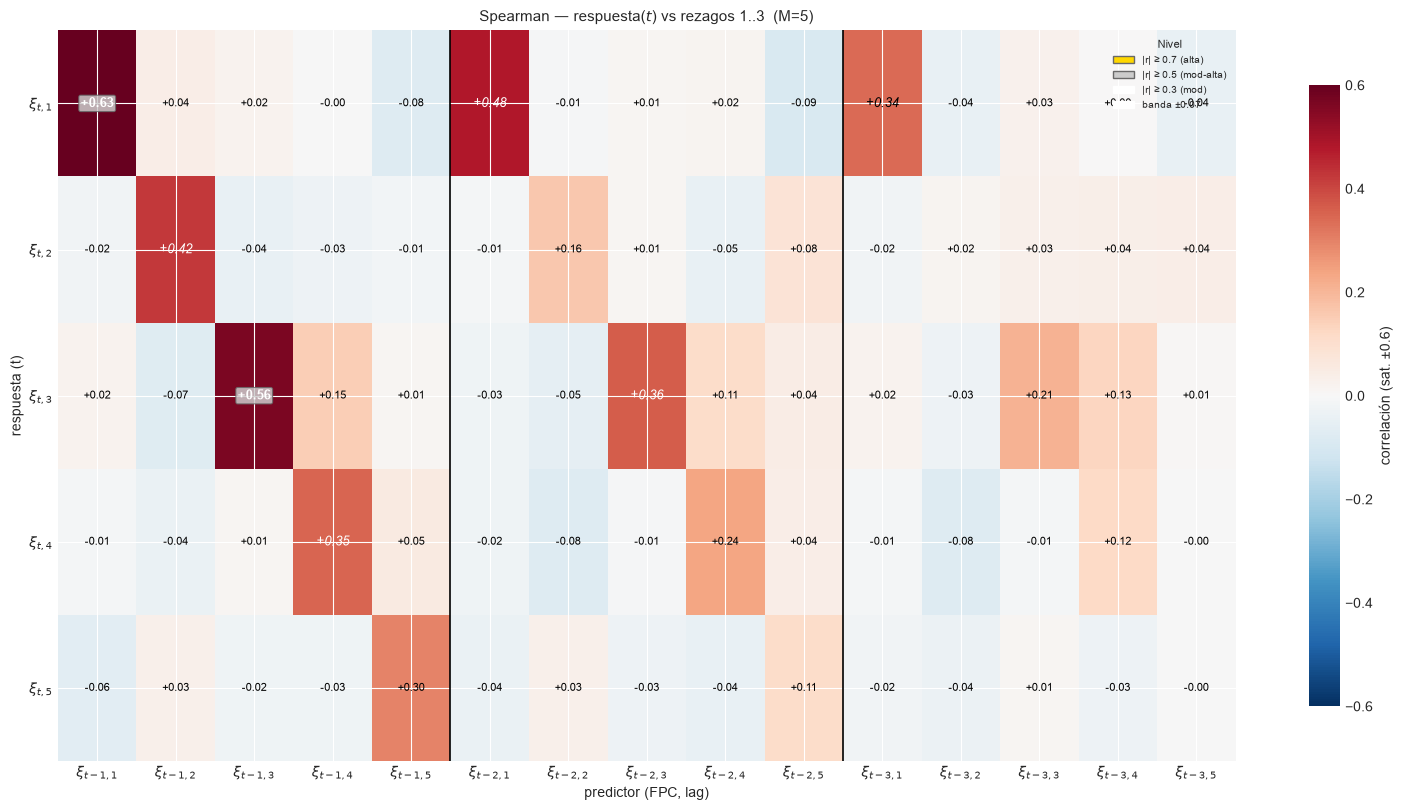

componentes : 5 -> índices [0, 1, 2, 3, 4]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4']
[functional] 10 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 15 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      btau  taupsij
   0    1   0.46743     2.14   0.23372  [4.687 4.674 4.632 4.633]
   1    2   0.29792     3.36   0.14896  [2.983 2.985 2.988 2.976]
   2    3   0.16505     6.06   0.08252  [1.653 1.652

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.2133,0.4194,-0.0102,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.2577,0.5022,-0.5071,1.4565,1.2068


contrato_ok = True   (M=5, K=10, T0=700, n_components=5)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 6   ·   escenario_200_chungEscG_1_r01_m06
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 6   <- DIFIERE de la regla: es un punto de sensibilidad
M = 6   var. explicada = 97.4576%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211 1.068 1.028]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


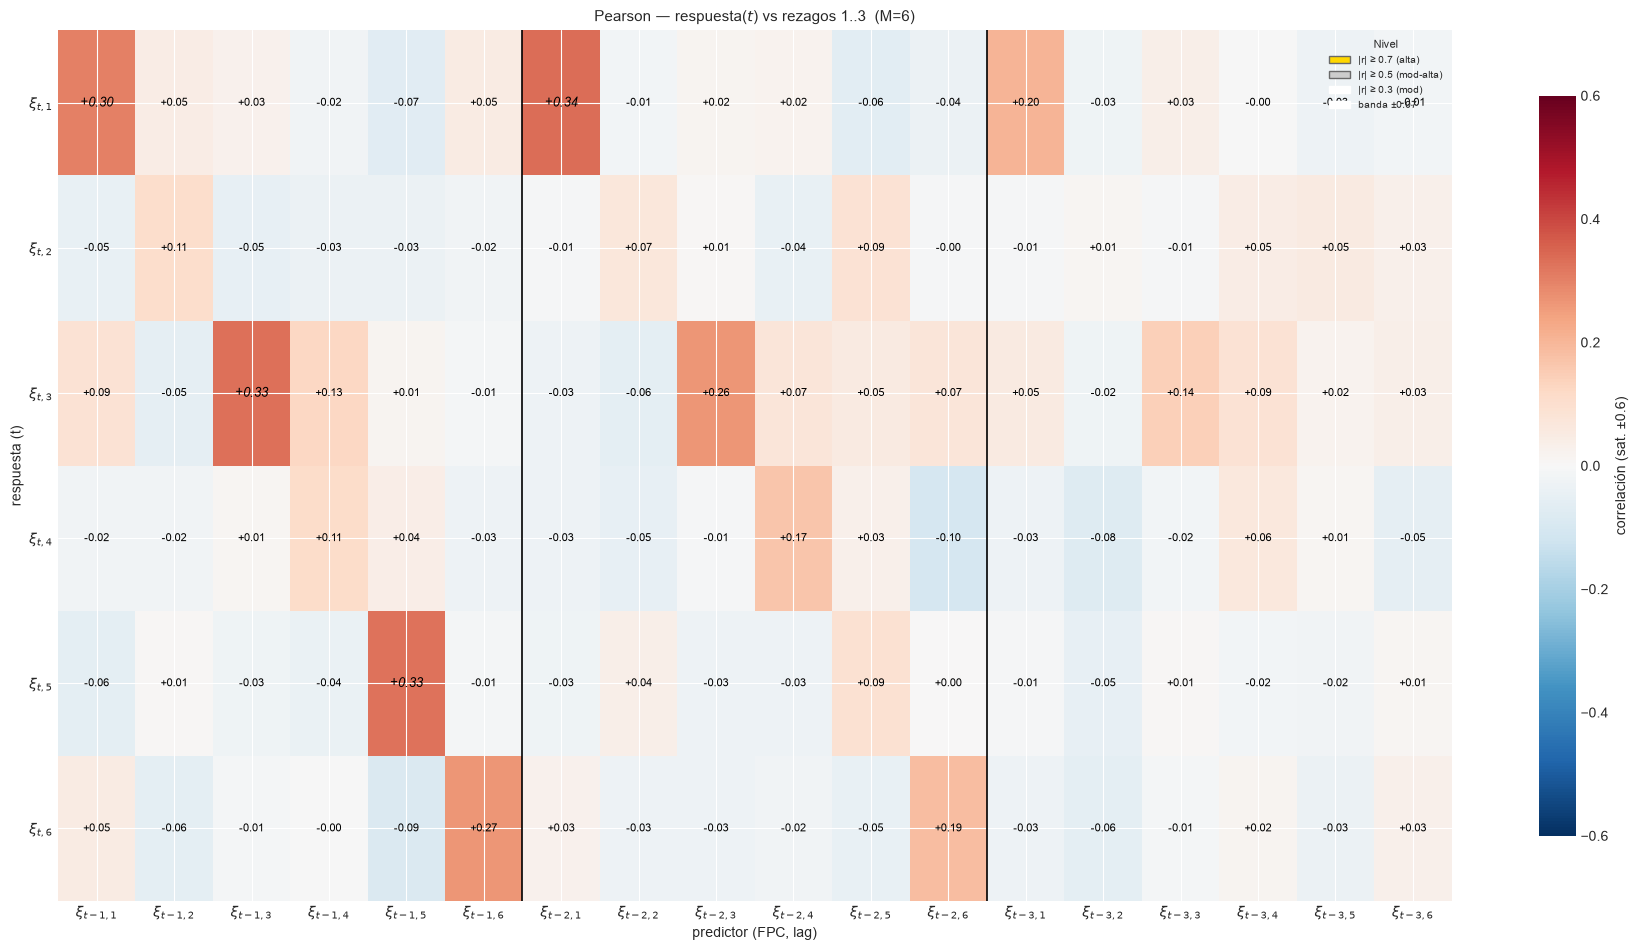

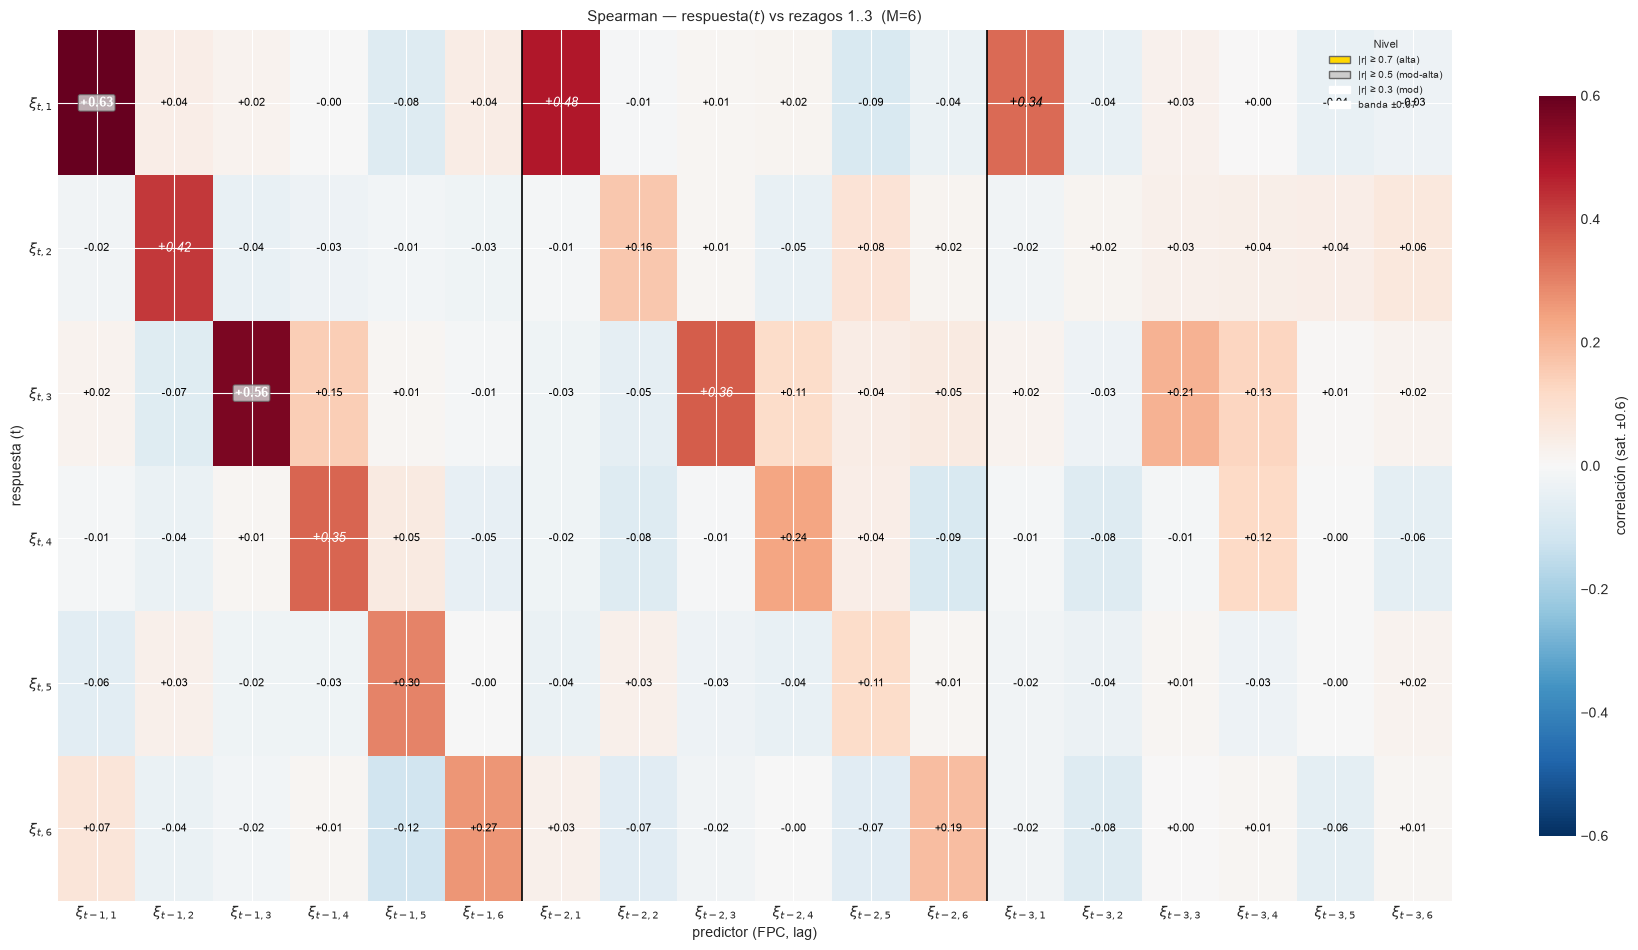

componentes : 6 -> índices [0, 1, 2, 3, 4, 5]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4']
[functional] 12 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 18 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      btau  taupsij
   0    1   0.46743     2.14   0.23372  [4.687 4.674 4.632 4.633]
   1    2   0.29792

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.2133,0.1596,0.3761,-0.0103,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.2577,0.1804,0.4486,-0.4713,1.4636,1.2098


contrato_ok = True   (M=6, K=10, T0=700, n_components=6)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 7   ·   escenario_200_chungEscG_1_r01_m07
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 7   <- DIFIERE de la regla: es un punto de sensibilidad
M = 7   var. explicada = 98.6746%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211 1.068 1.028 1.212]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


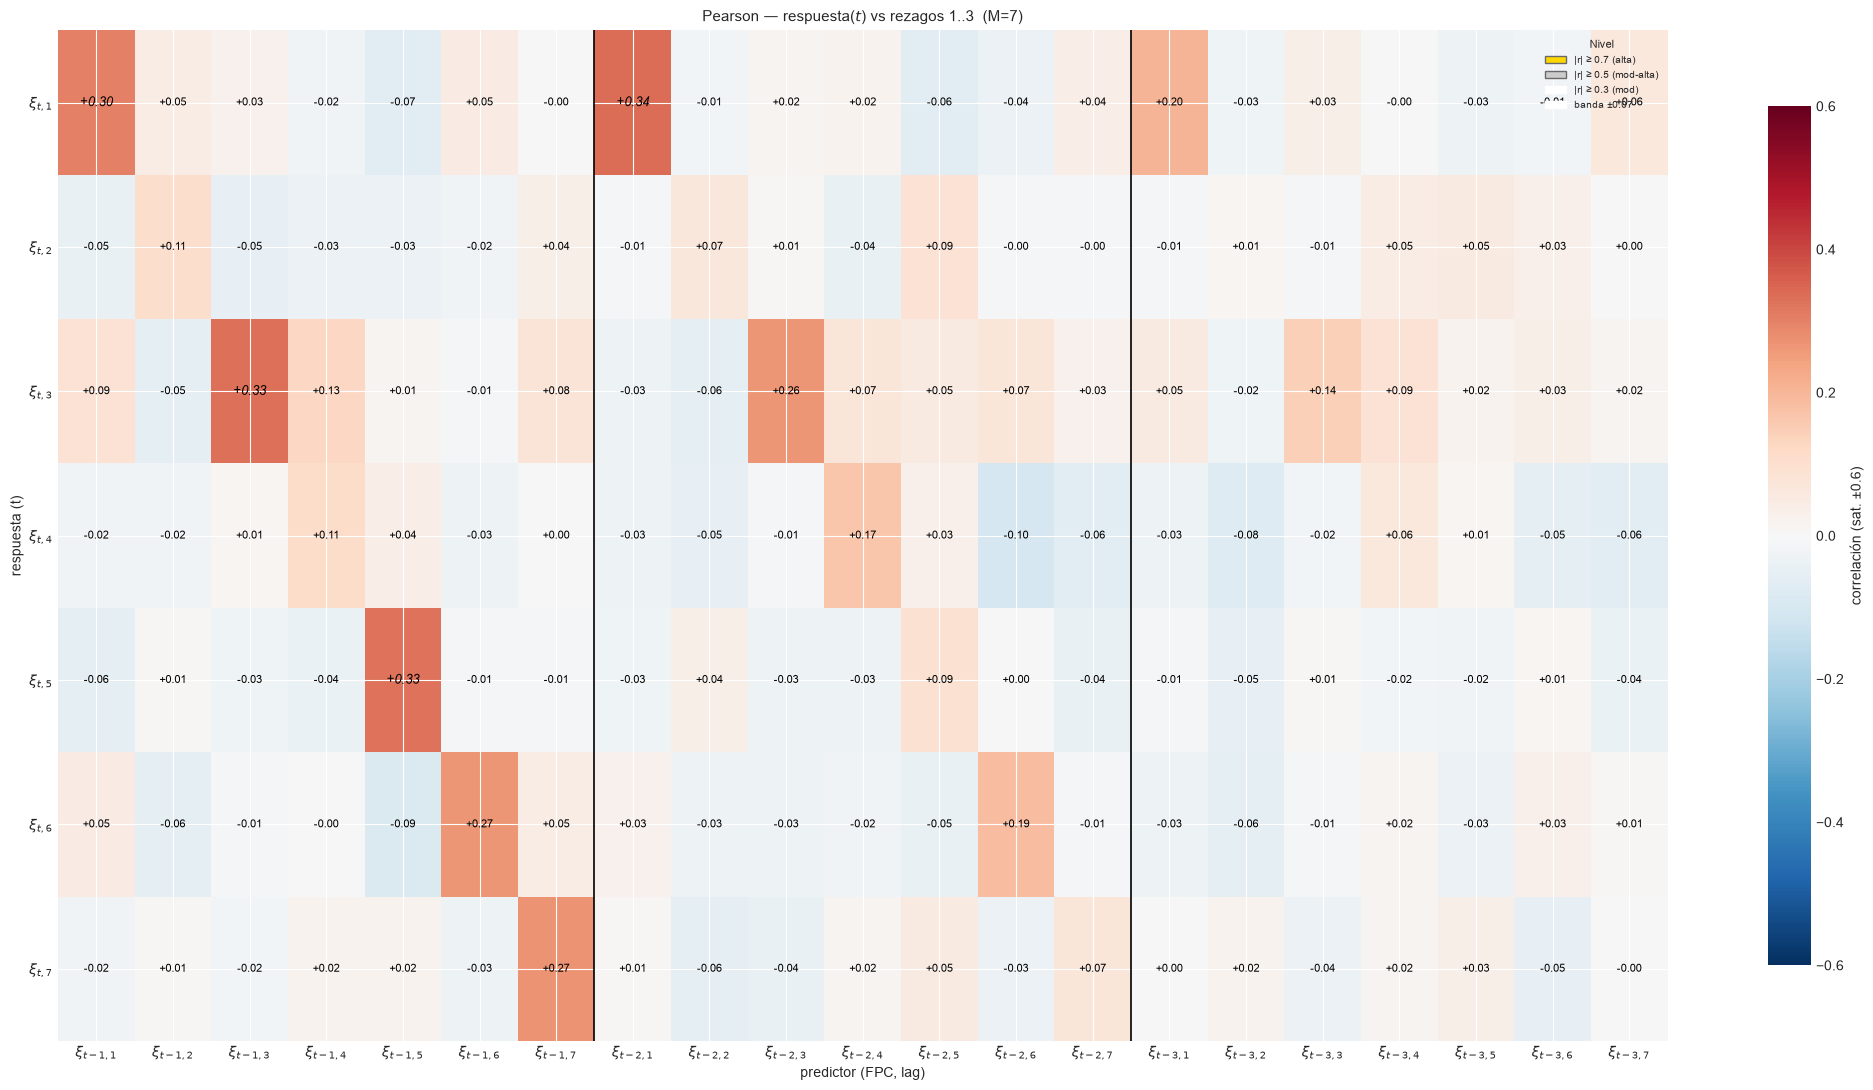

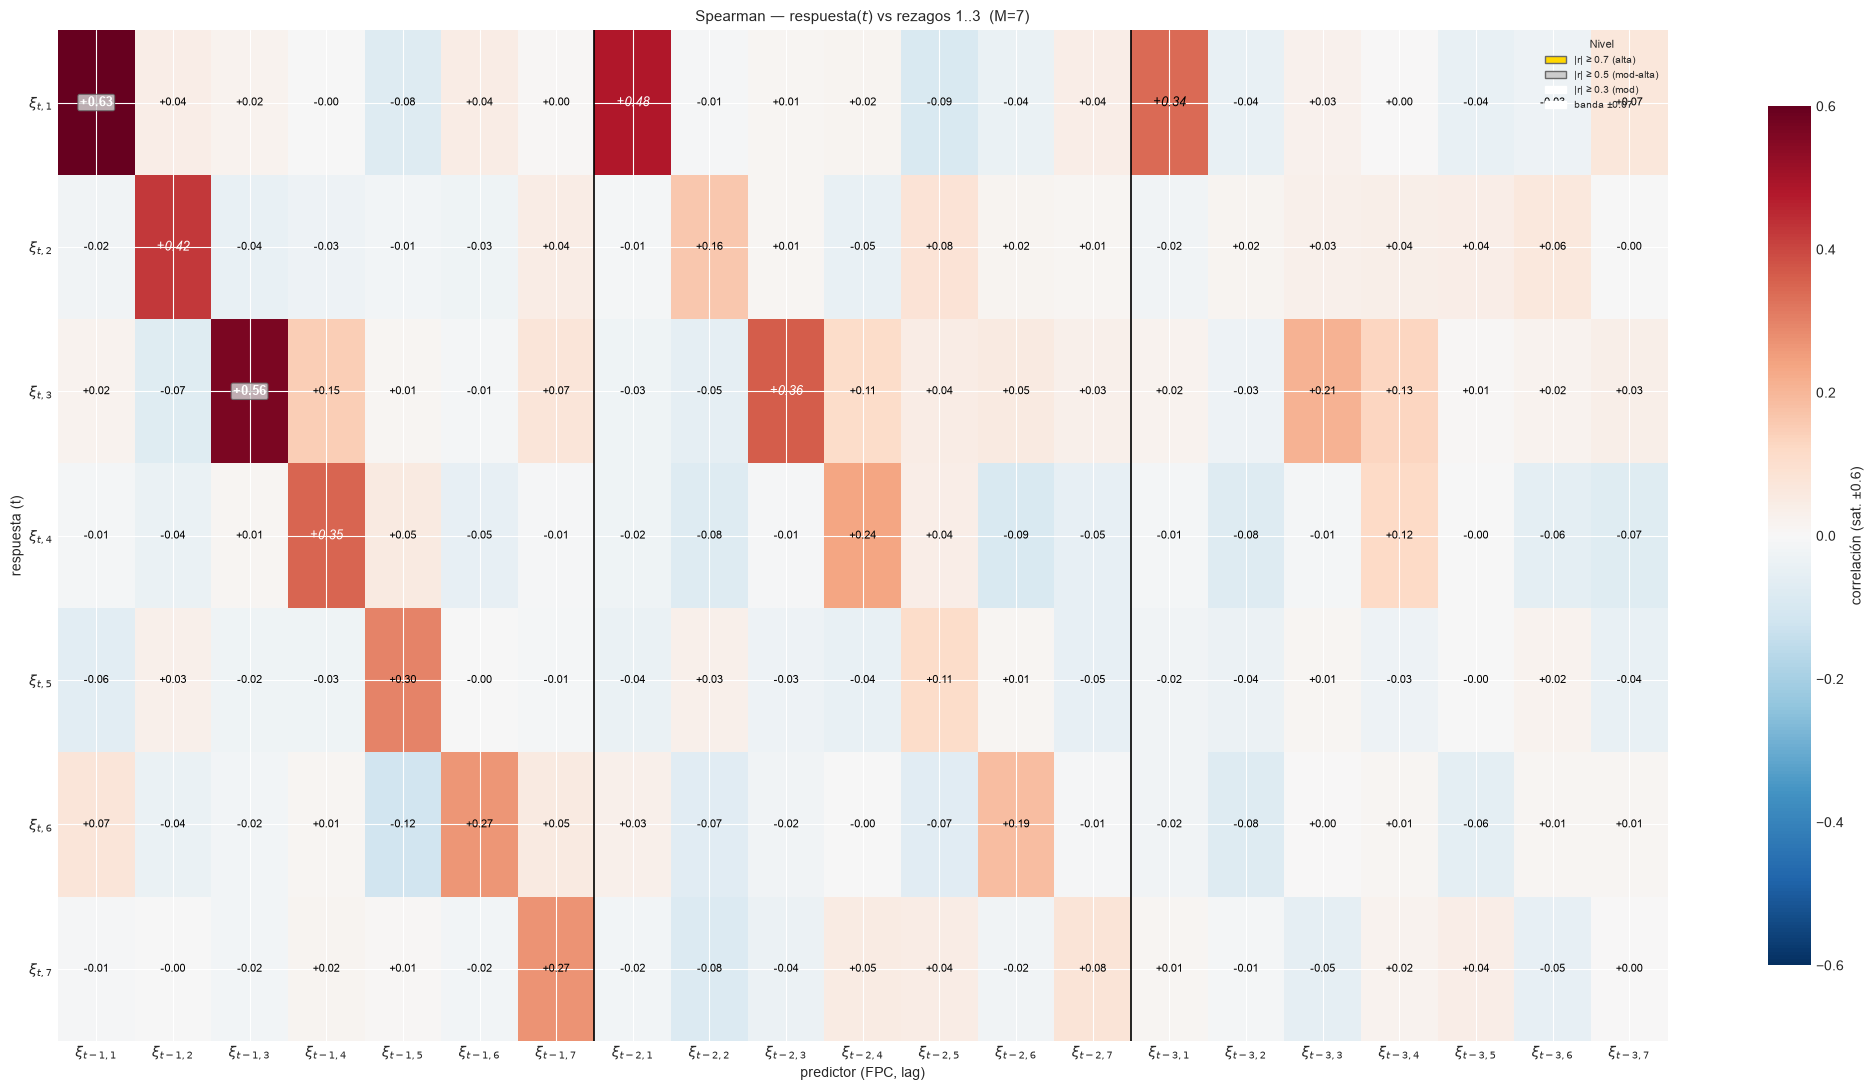

componentes : 7 -> índices [0, 1, 2, 3, 4, 5, 6]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_7_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4', 'fpc_7_lag4']
[functional] 14 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)
  fpc_7: train (696, 5) · test (300, 5)

N_CHAINS = 3 cadenas por componente -> 21 jobs en MATLAB para este M
   k  fpc    var(y)   E[tau]      

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.2133,0.1596,0.1290,0.3408,-0.0123,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.2577,0.1804,0.1453,0.4053,-0.4466,1.4680,1.2116


contrato_ok = True   (M=7, K=10, T0=700, n_components=7)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 8   ·   escenario_200_chungEscG_1_r01_m08
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 8   <- DIFIERE de la regla: es un punto de sensibilidad
M = 8   var. explicada = 99.4035%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211 1.068 1.028 1.212 0.949]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


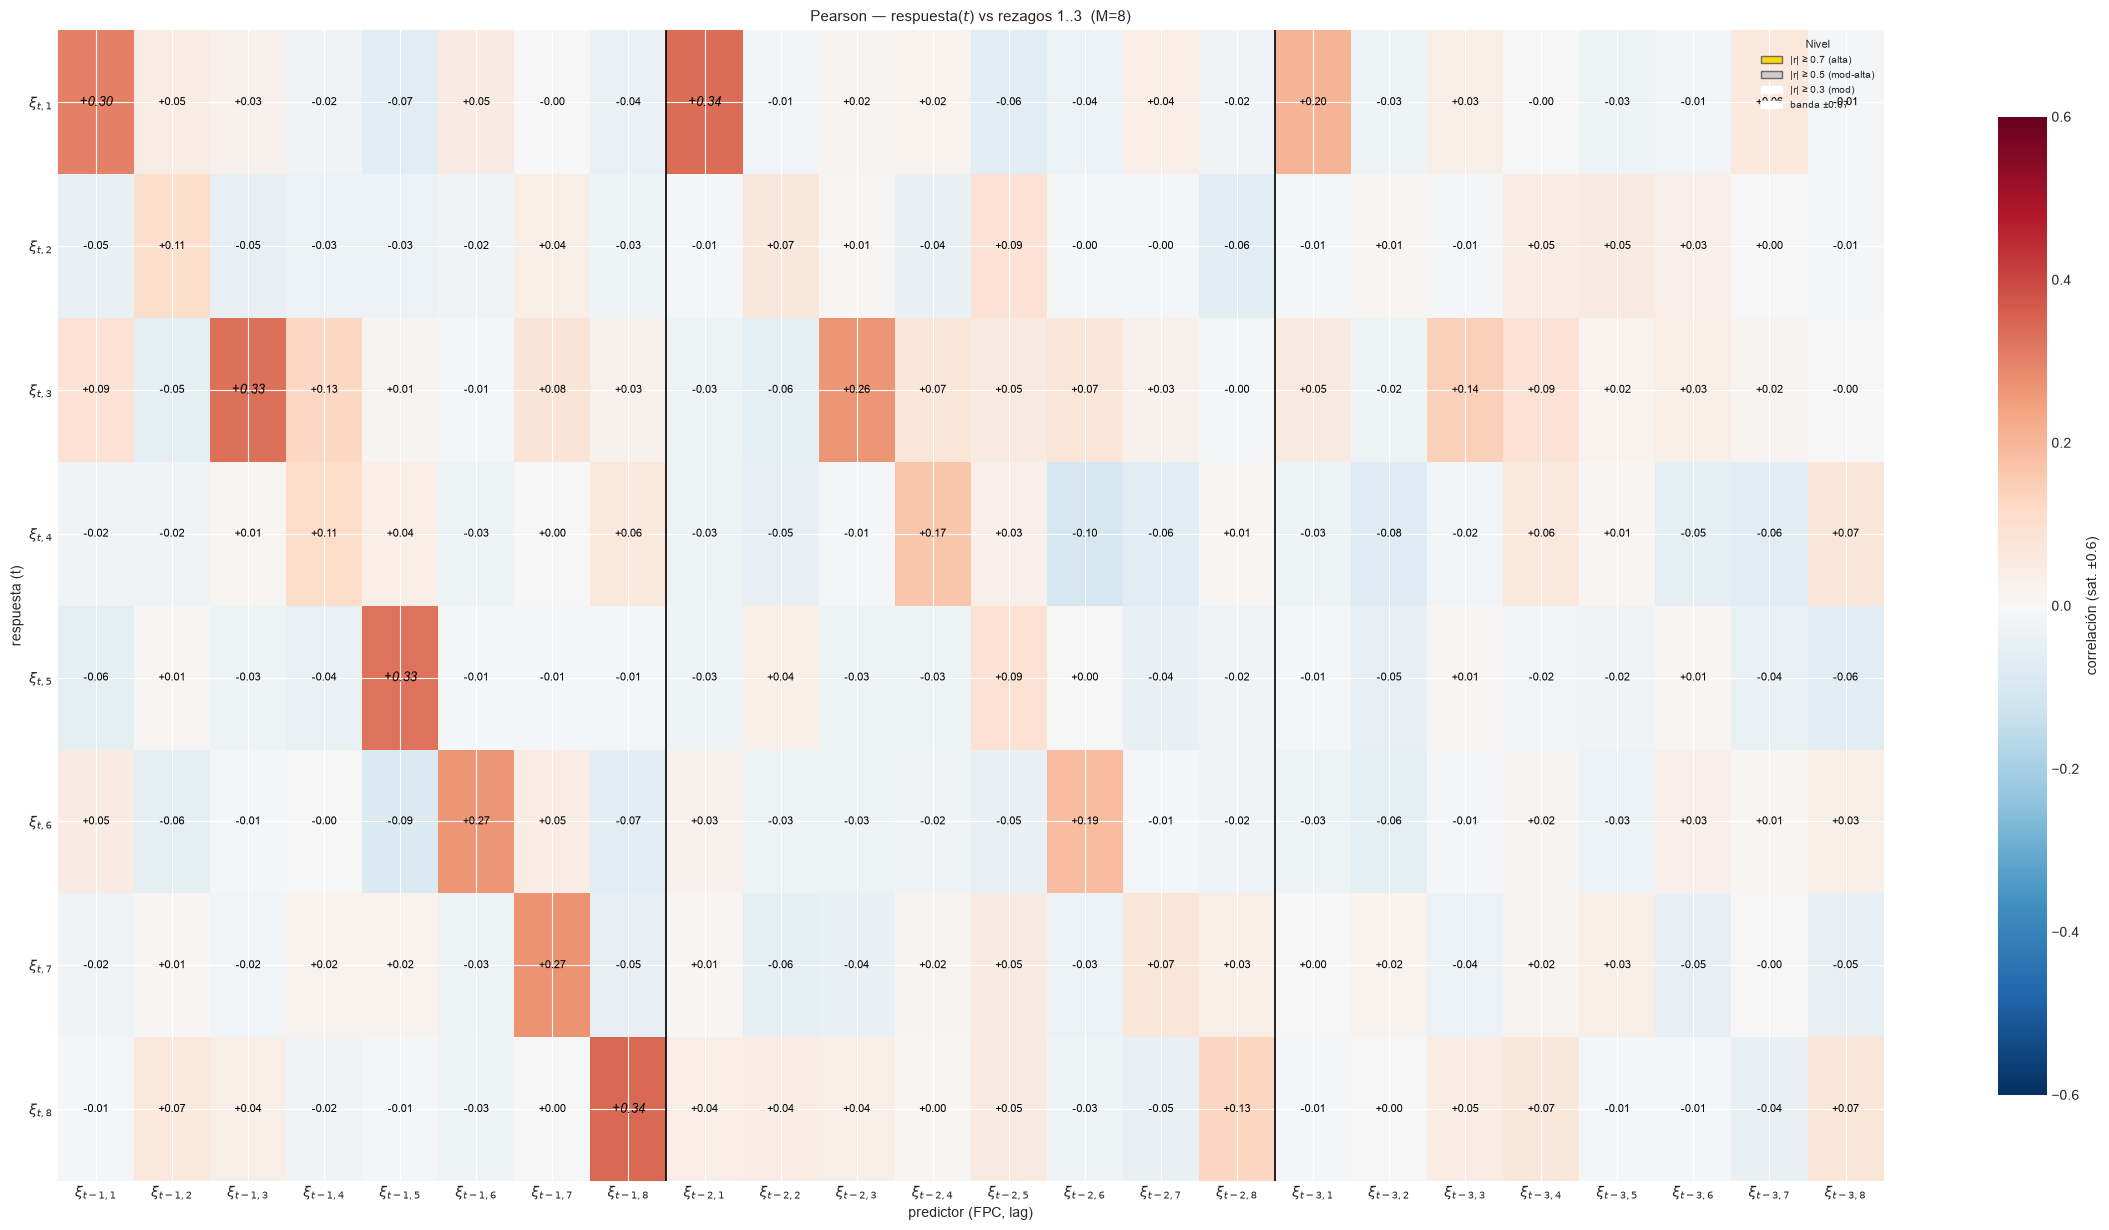

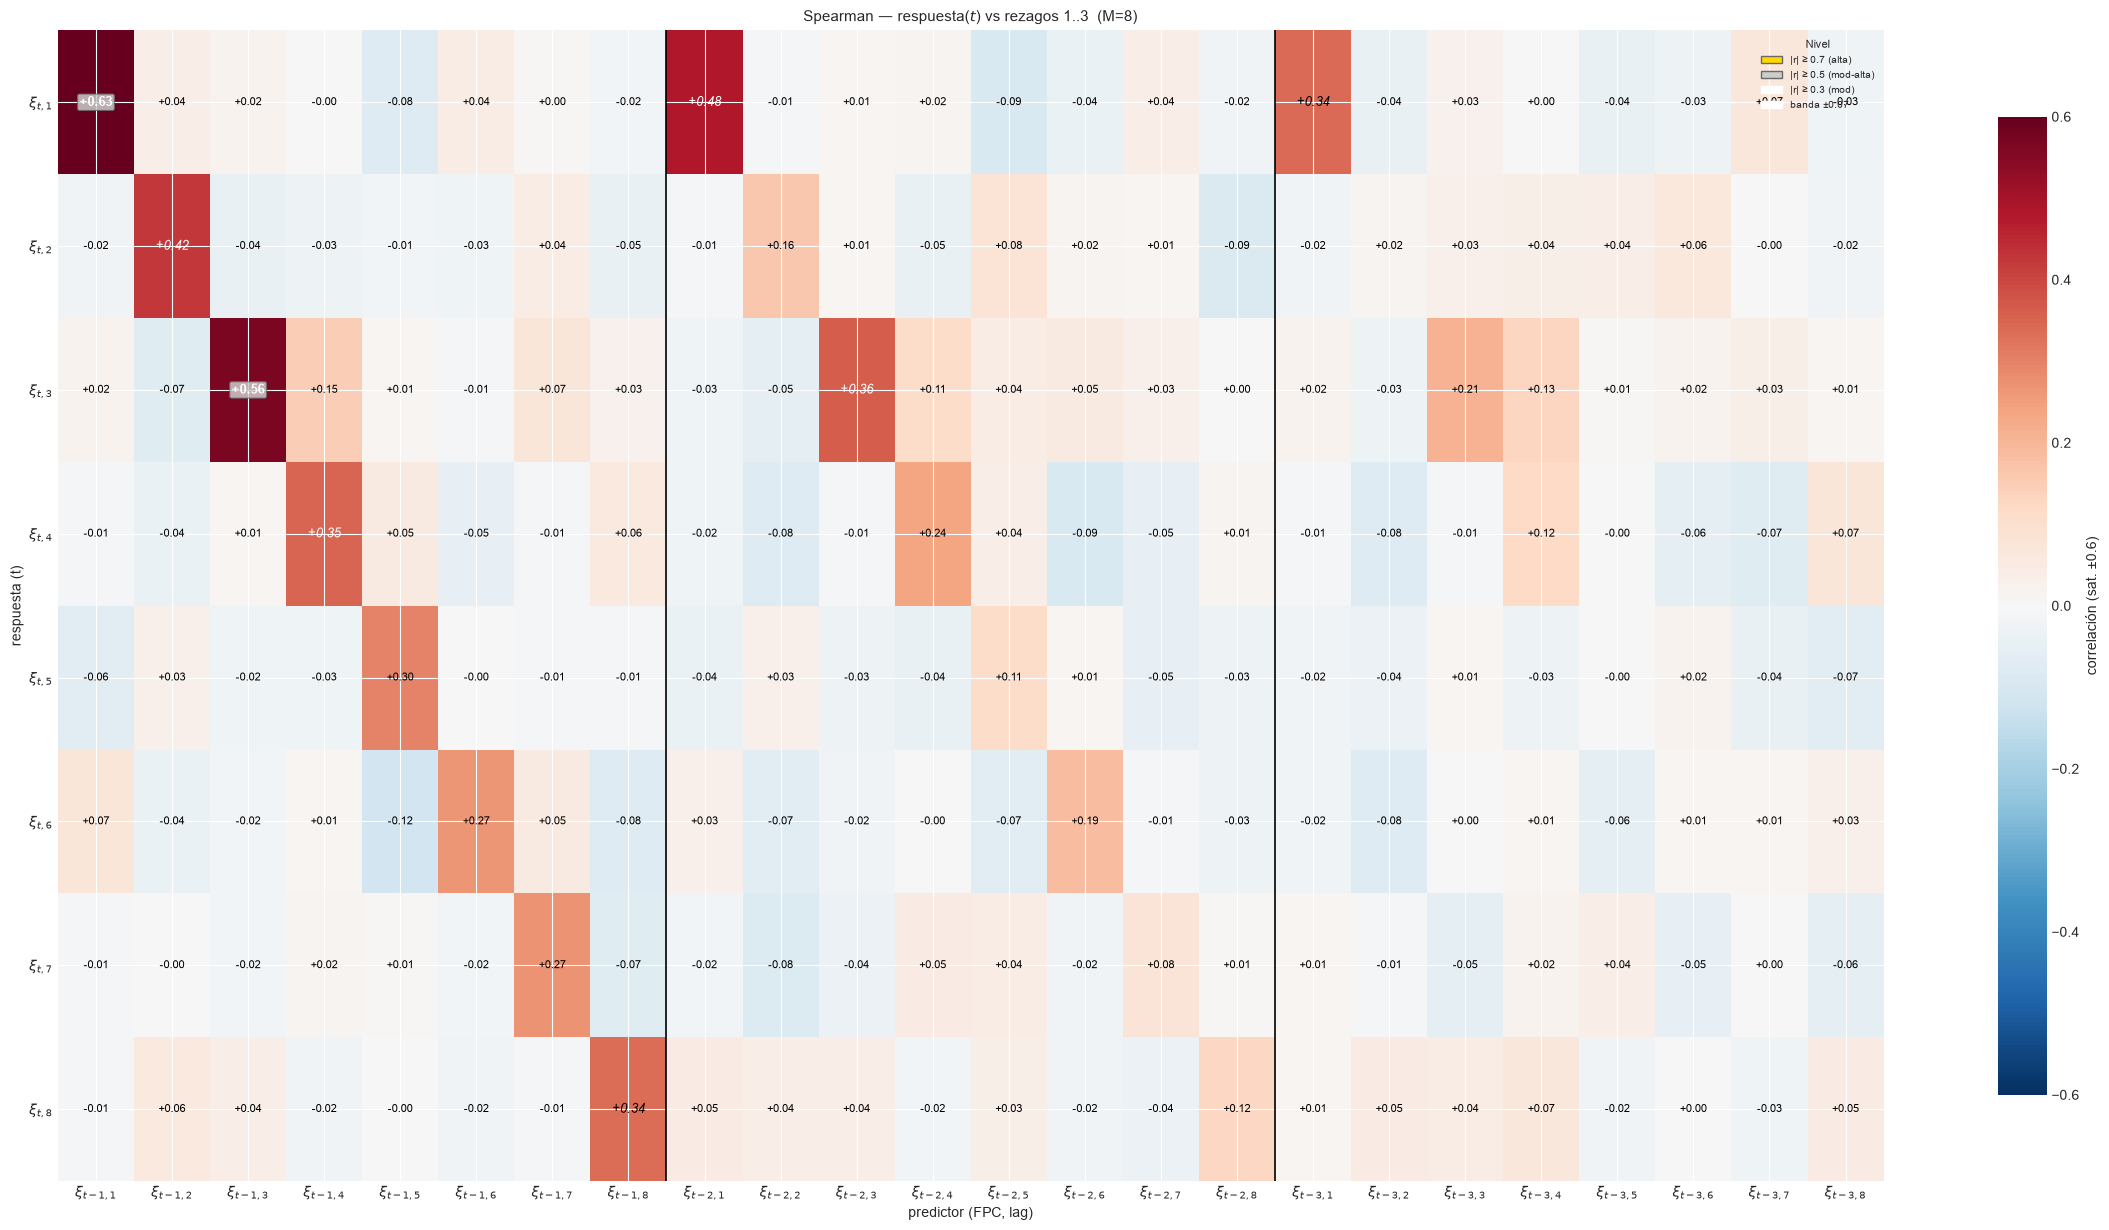

componentes : 8 -> índices [0, 1, 2, 3, 4, 5, 6, 7]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_7_lag3', 'fpc_8_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4', 'fpc_7_lag4', 'fpc_8_lag4']
[functional] 16 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)
  fpc_7: train (696, 5) · test (300, 5)
  fpc_8: train (696, 5) · test (300, 5)

N_CH

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.2133,0.1596,0.1290,0.0876,0.3092,-0.0114,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.2577,0.1804,0.1453,0.1060,0.3678,-0.4499,1.4716,1.2131


contrato_ok = True   (M=8, K=10, T0=700, n_components=8)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 9   ·   escenario_200_chungEscG_1_r01_m09
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 9   <- DIFIERE de la regla: es un punto de sensibilidad
M = 9   var. explicada = 99.7962%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211 1.068 1.028 1.212 0.949 1.038]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


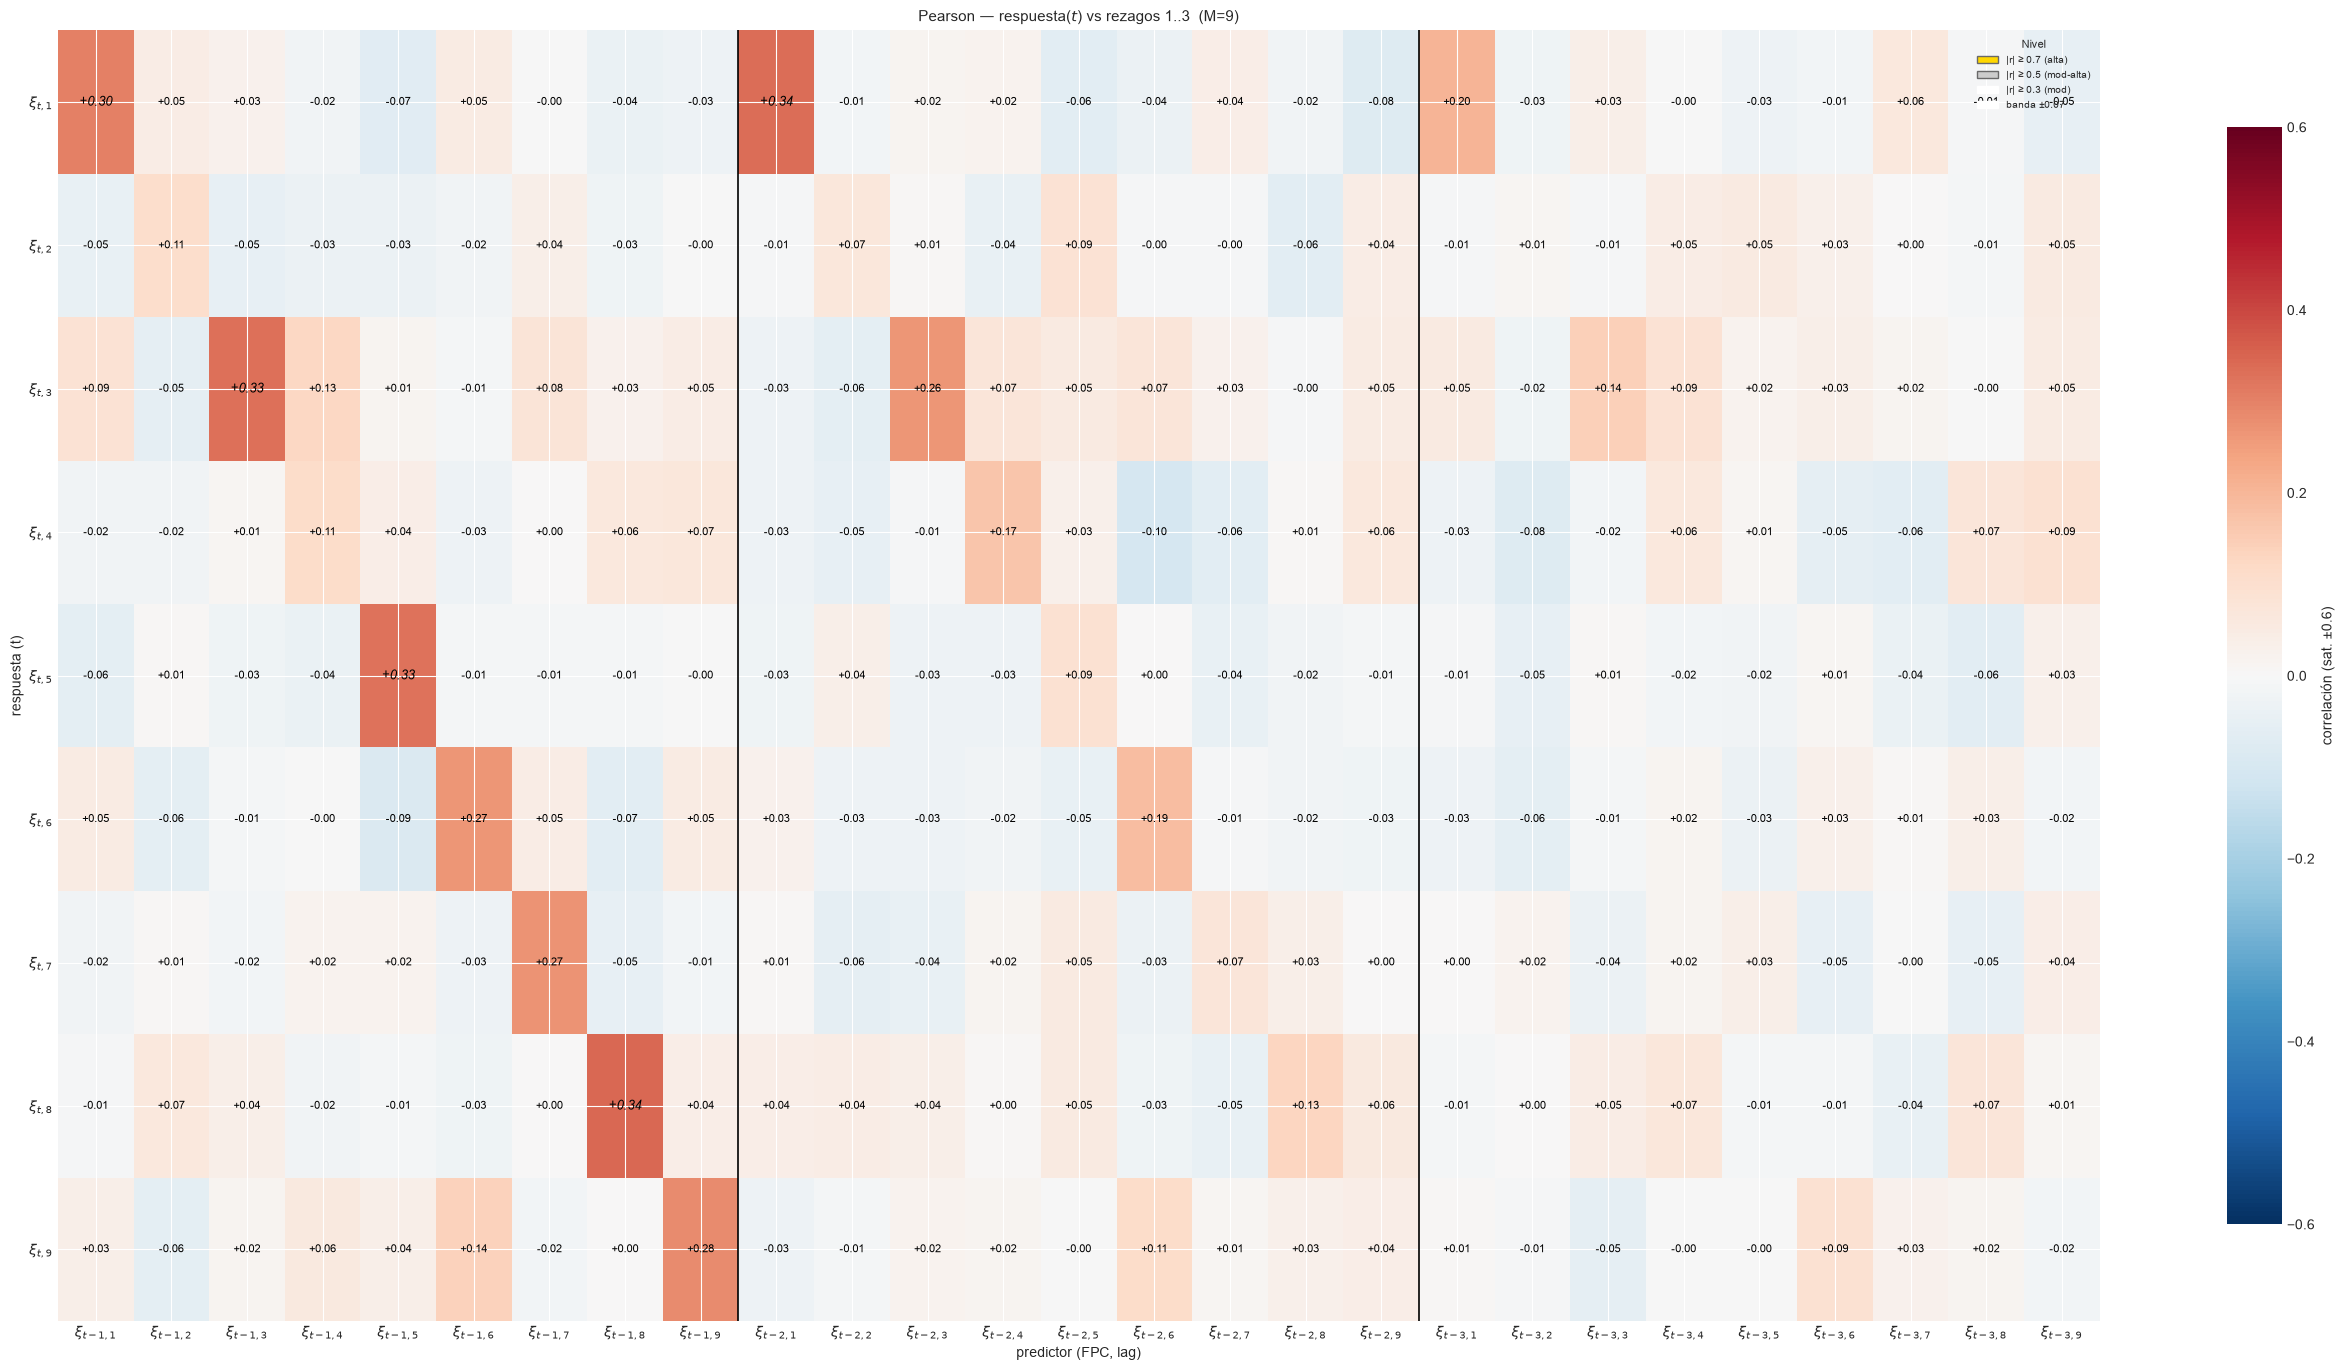

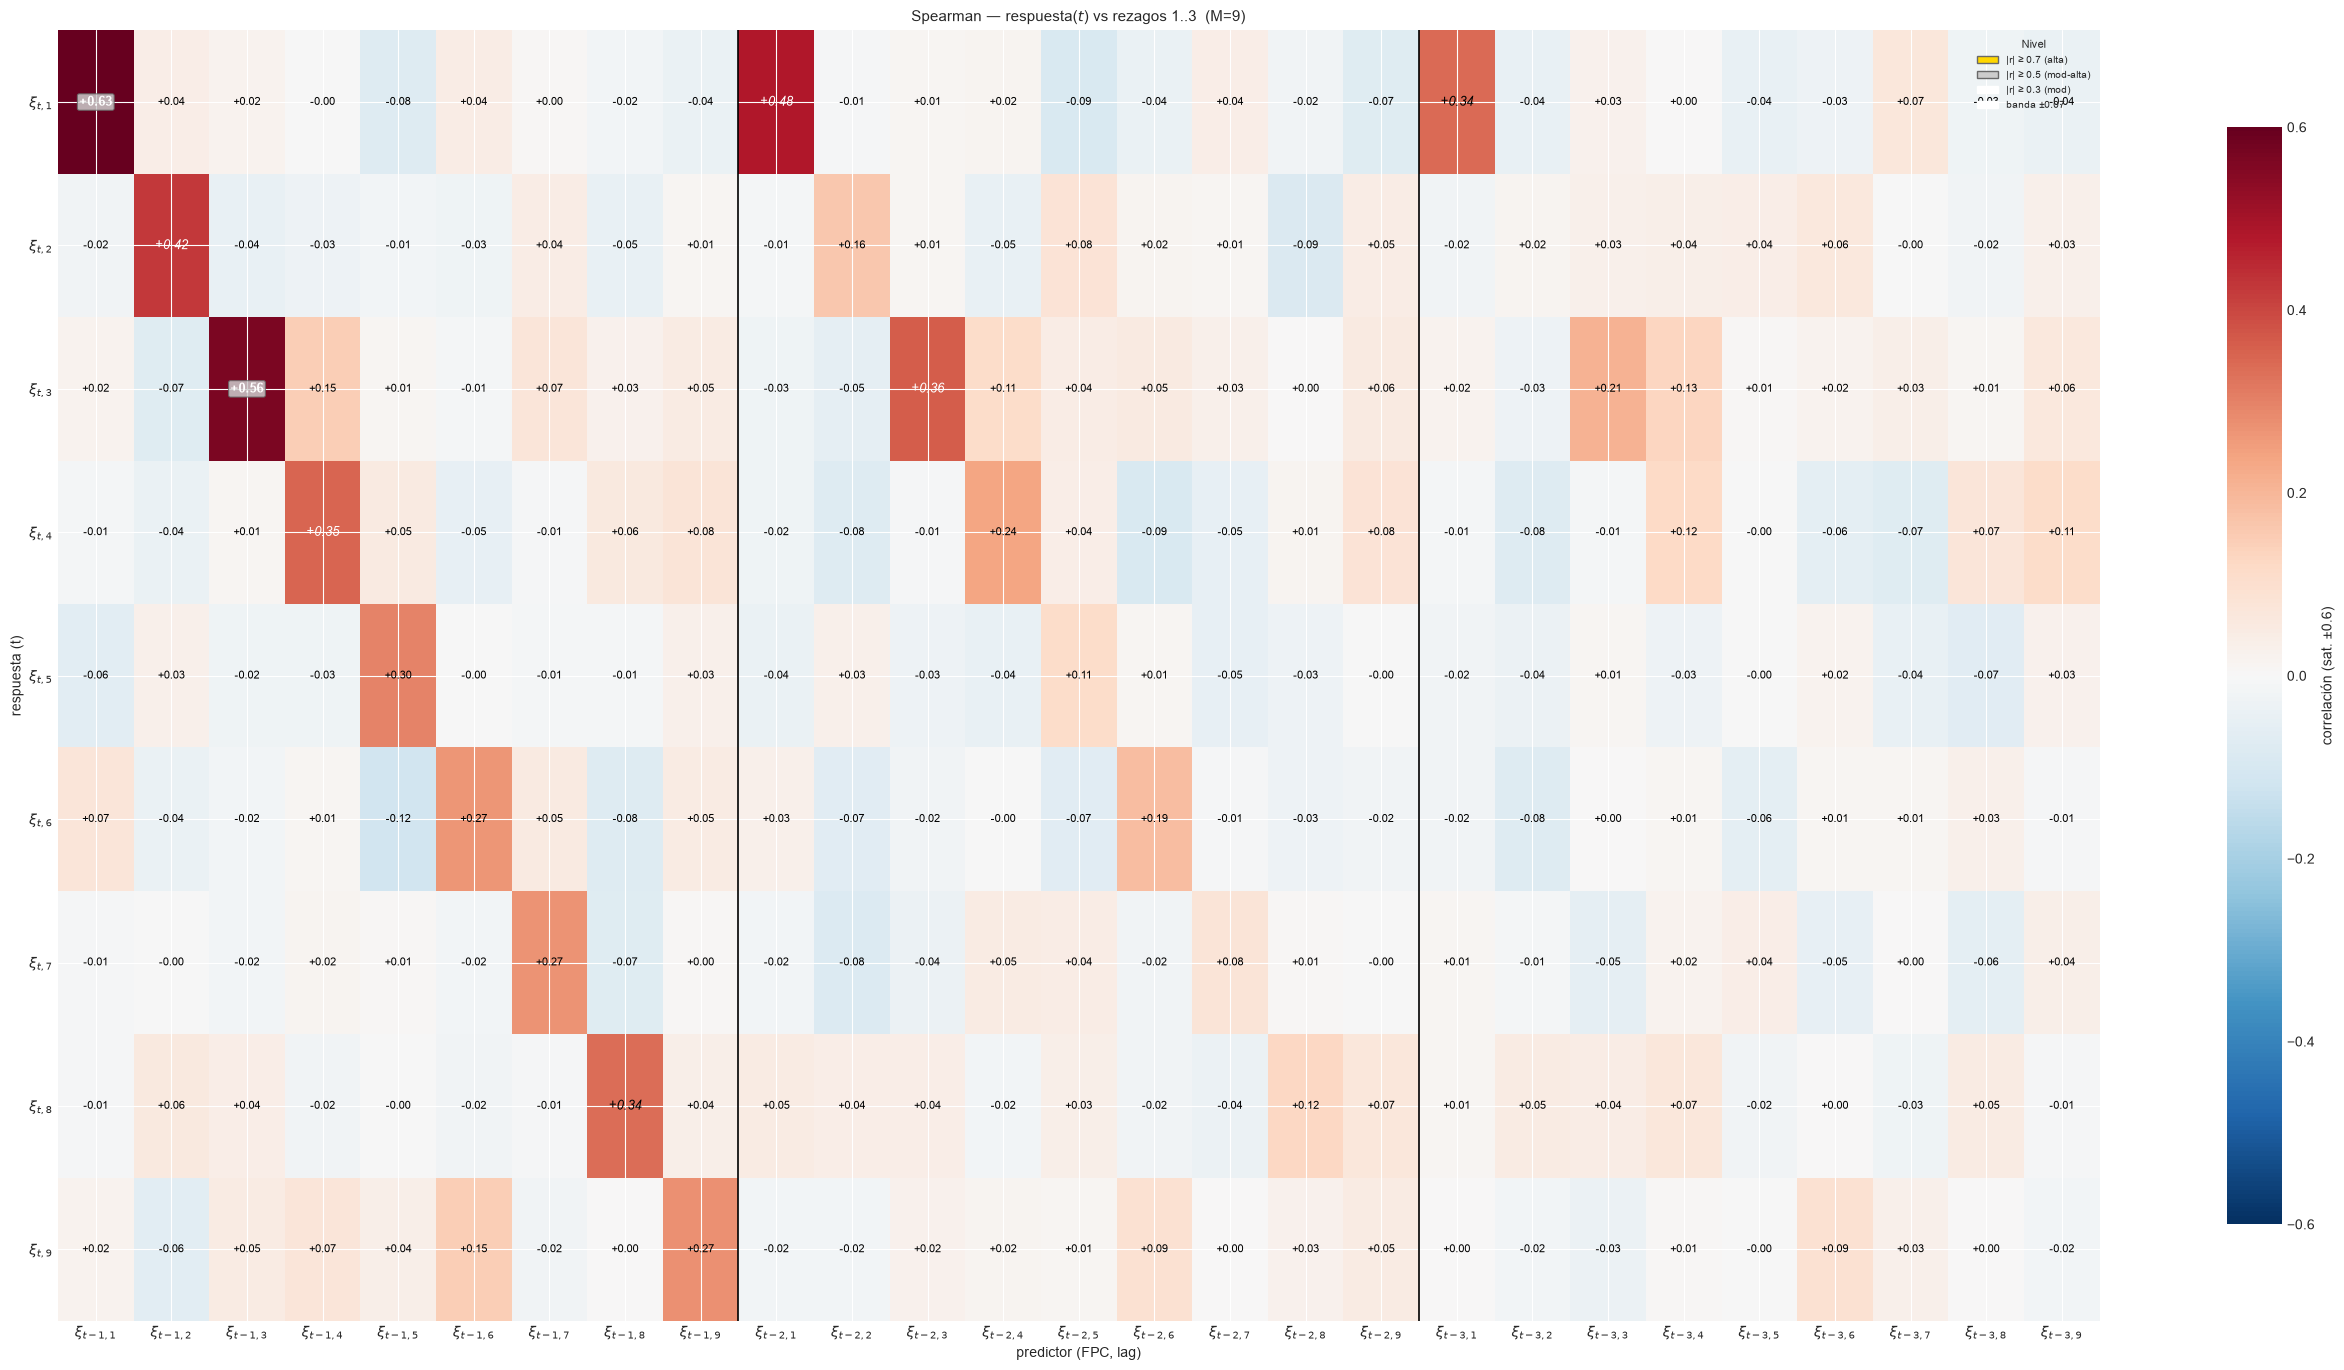

componentes : 9 -> índices [0, 1, 2, 3, 4, 5, 6, 7, 8]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_9_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_7_lag3', 'fpc_8_lag3', 'fpc_9_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4', 'fpc_7_lag4', 'fpc_8_lag4', 'fpc_9_lag4']
[functional] 18 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)
  fpc_7: train (696, 5) · 

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_fpc9,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.2133,0.1596,0.1290,0.0876,0.0674,0.2823,-0.0112,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.2577,0.1804,0.1453,0.1060,0.0816,0.3360,-0.4532,1.4737,1.2140


contrato_ok = True   (M=9, K=10, T0=700, n_components=9)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 10   ·   escenario_200_chungEscG_1_r01_m10
M(95 %) según la regla : 5   (K disponible = 10)
M de este punto        : 10   <- DIFIERE de la regla: es un punto de sensibilidad
M = 10   var. explicada = 100.0000%
[train] max|media xi| = 5.02e-02   (~ 0)
[test]  max|media xi| = 0.060
[test]  var xi / lambda = [0.946 0.89  0.912 1.211 1.068 1.028 1.212 0.949 1.038 0.963]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

[functional] artefactos FPCA · cond_W = 1.000e+00


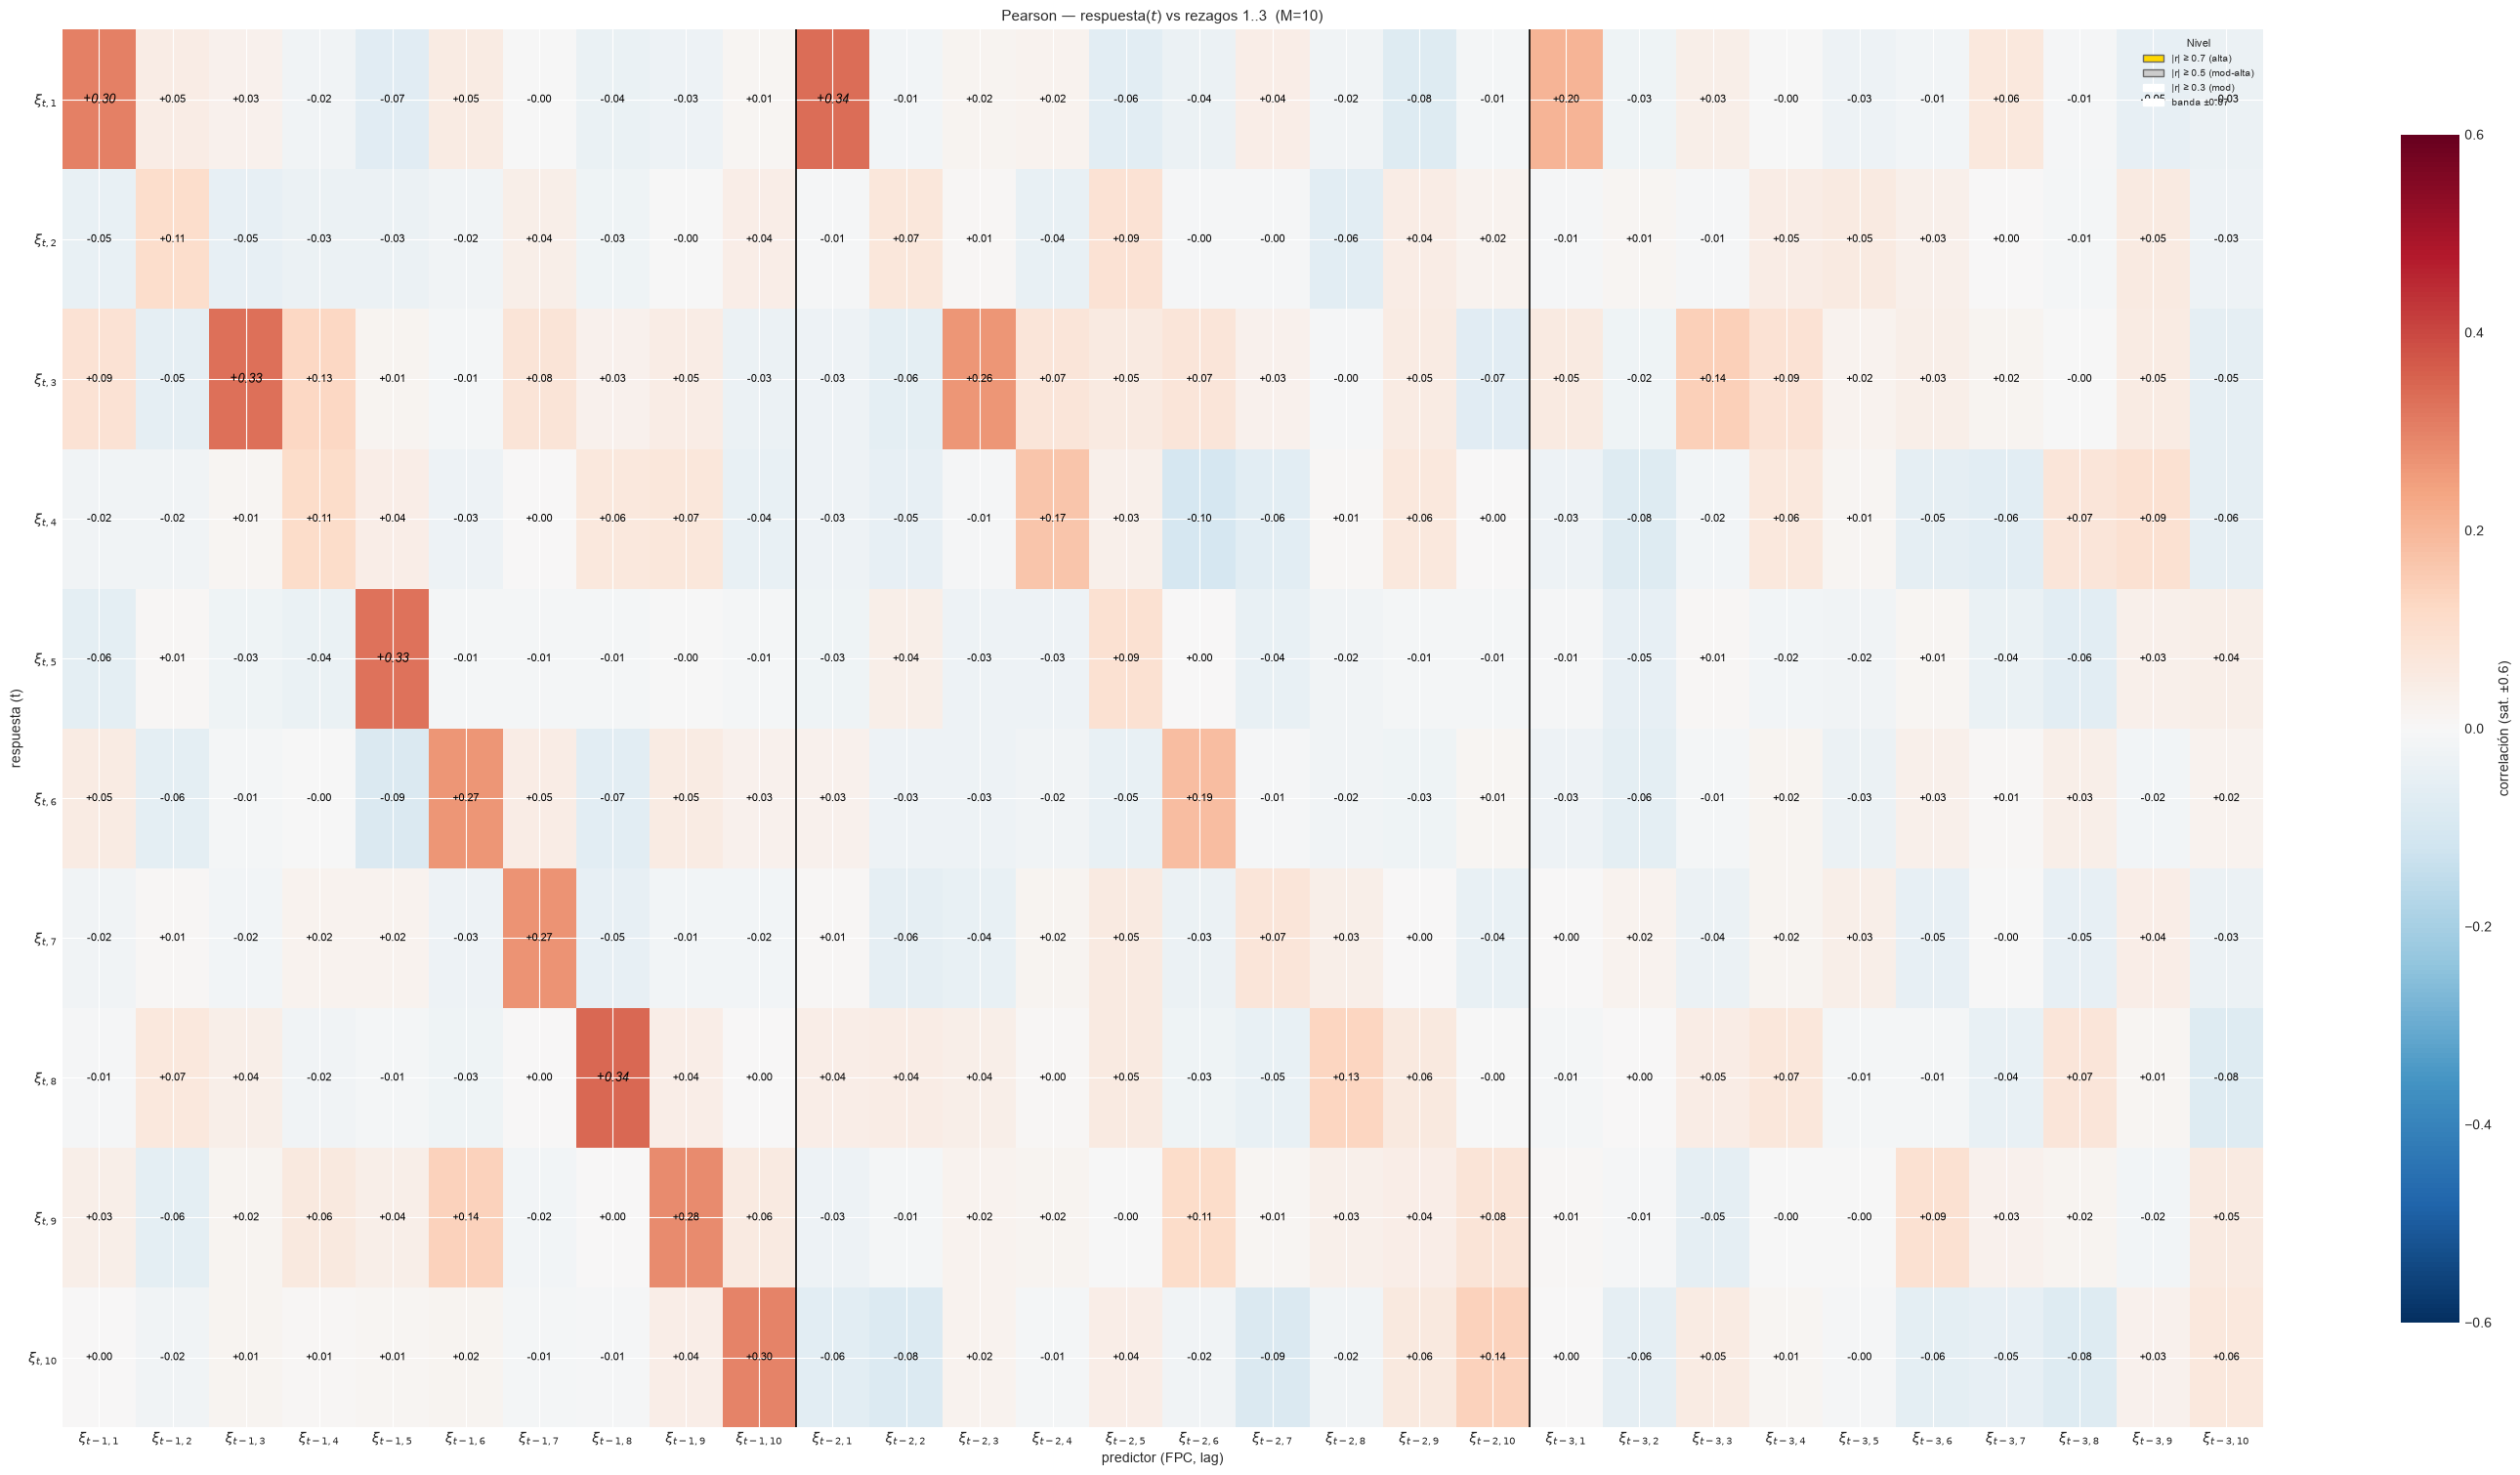

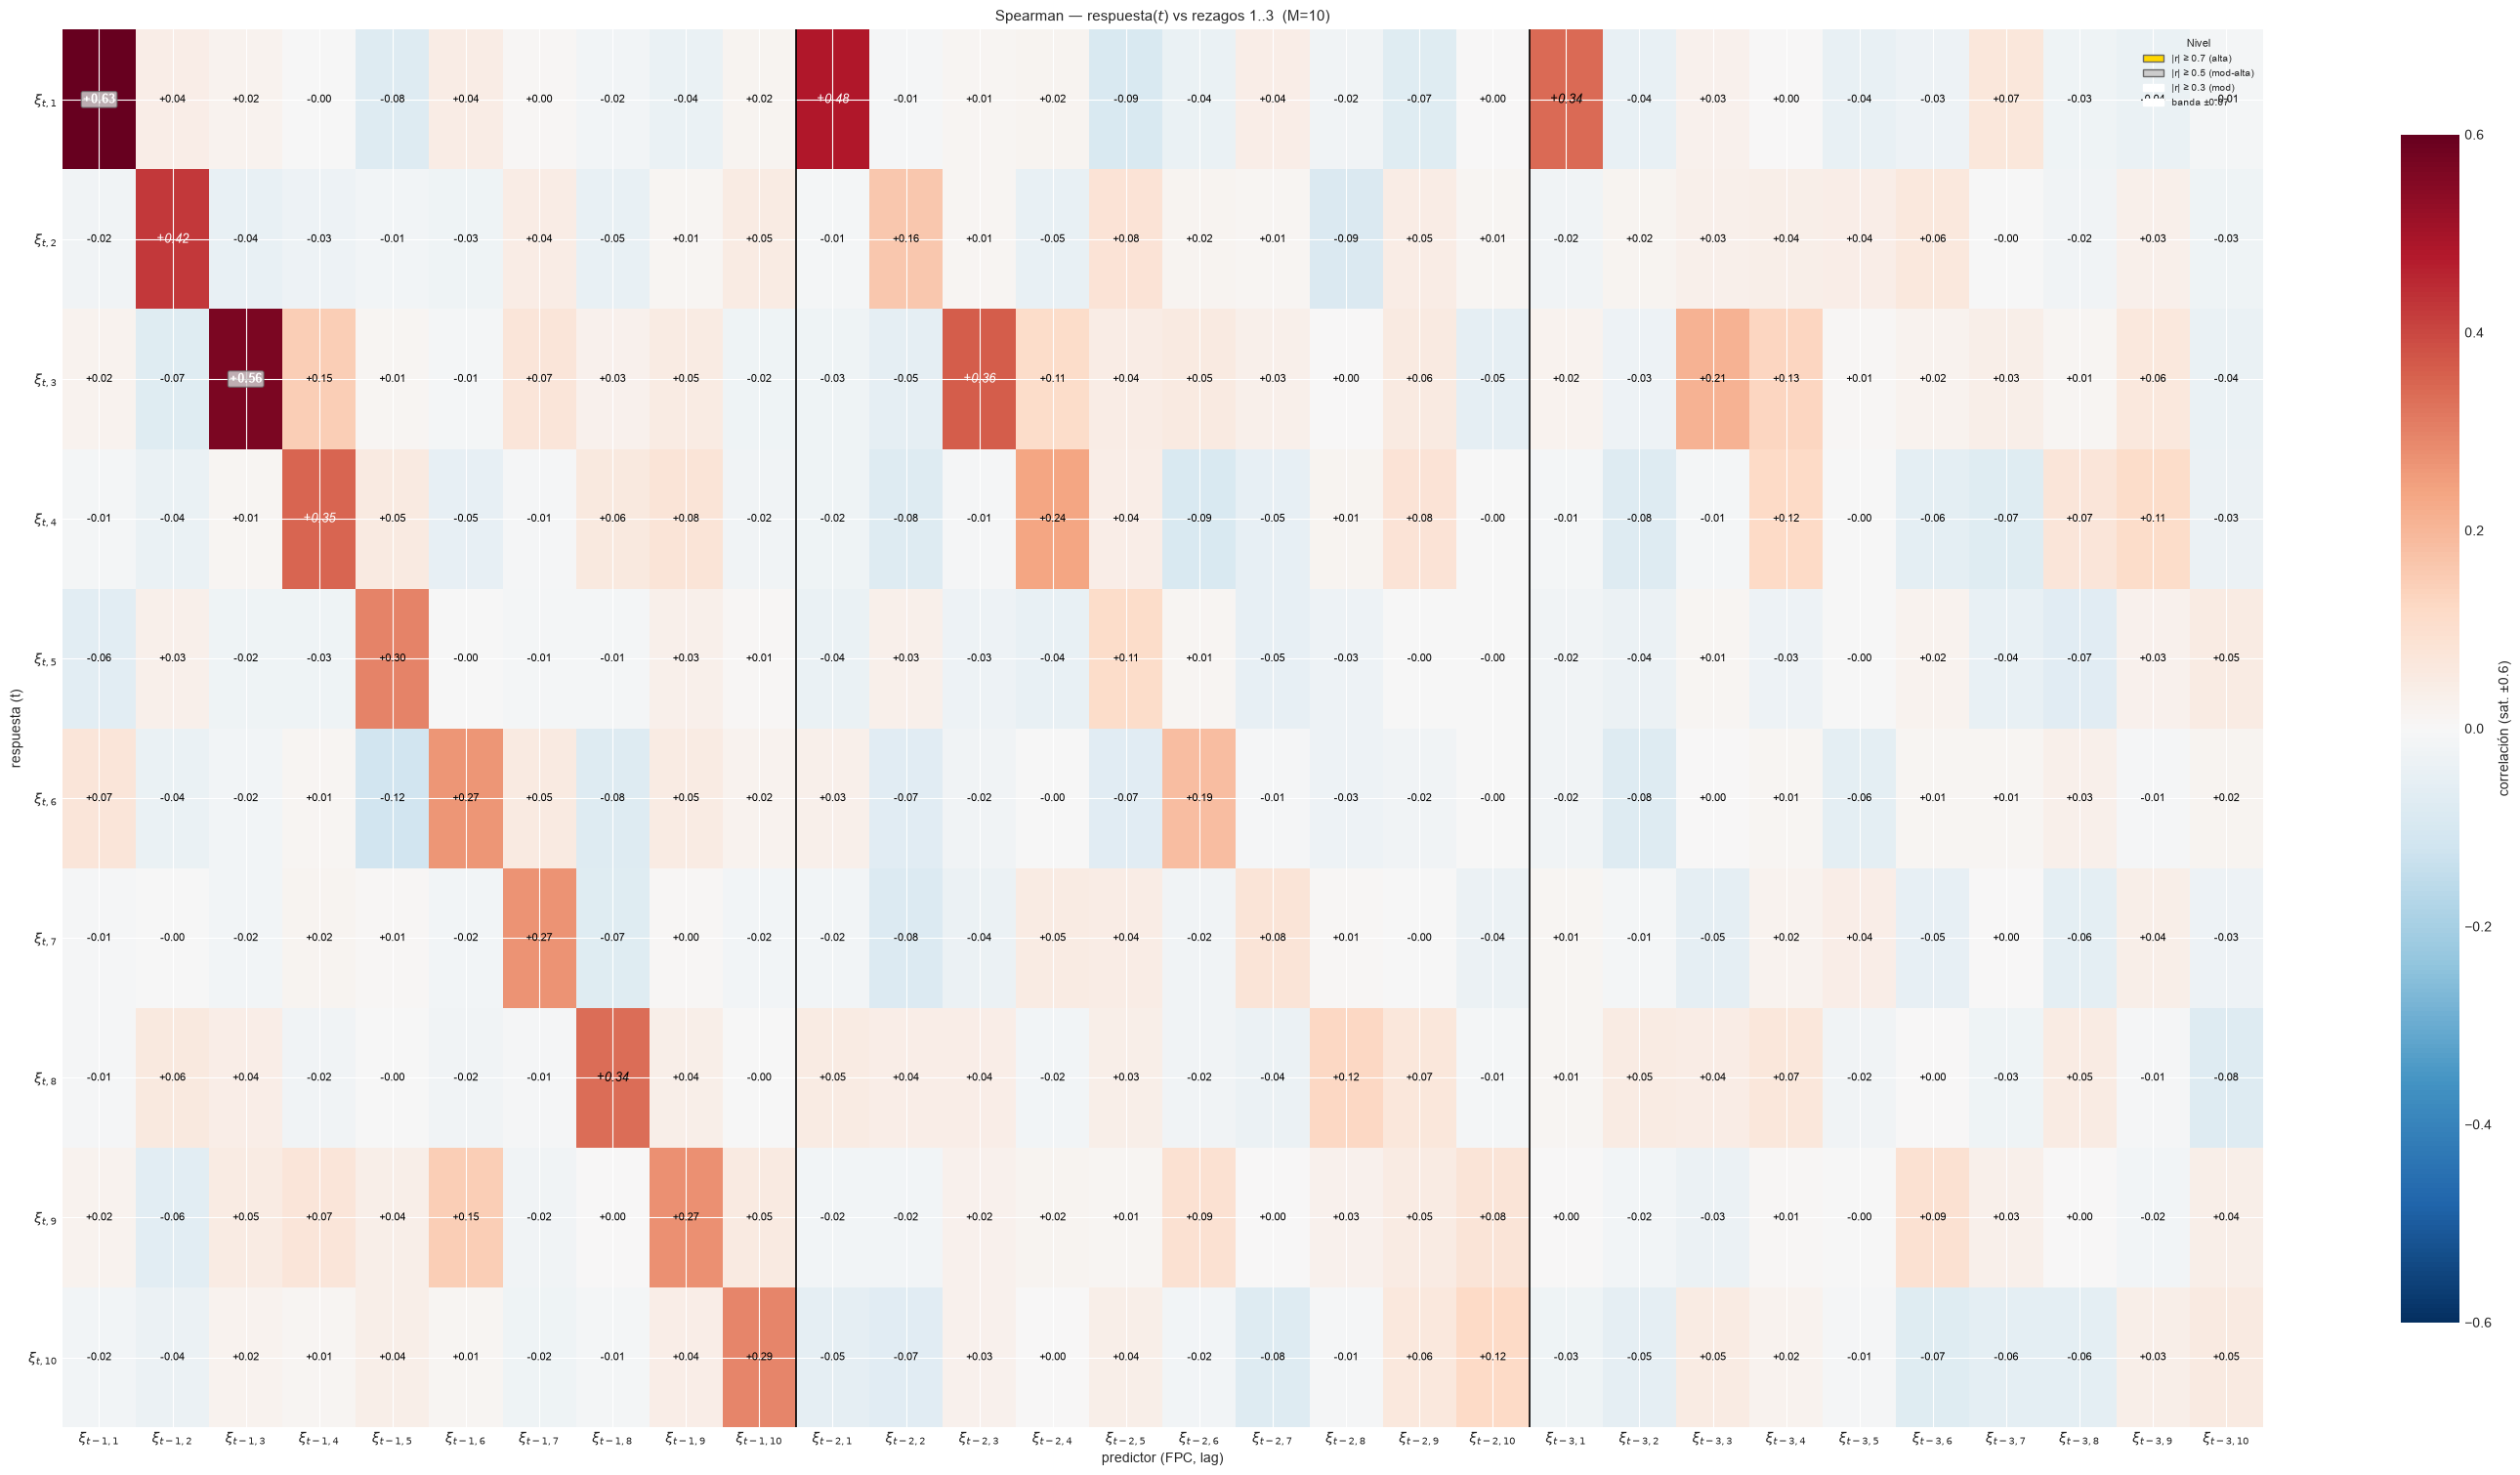

componentes : 10 -> índices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago_propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_10_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_9_lag2', 'fpc_10_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_7_lag3', 'fpc_8_lag3', 'fpc_9_lag3', 'fpc_10_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4', 'fpc_7_lag4', 'fpc_8_lag4', 'fpc_9_lag4', 'fpc_10_lag4']
[functional] 20 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_fpc9,RMSE_fpc10,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,,,
media_incondicional,300.0000,0.6659,0.5145,0.3878,0.3159,0.2133,0.1596,0.1290,0.0876,0.0674,0.0468,0.2588,-0.0113,1.0602,1.0297
persistencia_lag1,300.0000,0.6992,0.6792,0.4545,0.4204,0.2577,0.1804,0.1453,0.1060,0.0816,0.0566,0.3081,-0.4558,1.4747,1.2144


contrato_ok = True   (M=10, K=10, T0=700, n_components=10)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True


In [51]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# Rezago propio: xi_(k,t) se predice con xi_(k,t-l), l = 1..N_LAGS. N_LAGS es
# el L del anexo: no es perilla.
N_LAGS = 4
assert N_LAGS >= SIM_CFG.n_rezagos, (
    f"N_LAGS={N_LAGS} < n_rezagos={SIM_CFG.n_rezagos} del simulador: el pipeline debe ver al menos los rezagos del generador.")

MCMC_CONFIG = {"nsim": 2500, "burn": 500, "N": VAR_CFG["N"], "M": 50}   # ojo: ese M es G*
N_CHAINS    = 3

HP_GLOBAL = {"atau": 0.5, "btau": 0.5, "ag": 0.5, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Chung §4.2 llevado a la escala cruda. Si x = sd*z, el prior del paper sobre z
# equivale a taupsij = taupsij_z*sd_x^2 y btau = 0.5*sd_y^2 (se aplican en
# procesar_punto). Inclusion: Chung en el lag 1, bpij = 5 del lag 2 en adelante.
HP_CHUNG_ESC = {"taupsij_z": float(VAR_CFG.get("taupsij_z", 100.0)), "btau_z": 0.5,
                "ab_por_lag": {l: (0.5, 0.5) if l == 1 else (0.5, 5.0)
                               for l in range(1, N_LAGS + 1)},
                "ab_cruzado": (0.5, 5.0)}
HP_BY_TYPE = {f"own_lag{l}": {"apij": HP_CHUNG_ESC["ab_por_lag"][l][0],
                              "bpij": HP_CHUNG_ESC["ab_por_lag"][l][1]}
              for l in range(1, N_LAGS + 1)}
# Cruzados (variante chungEscX): mismo prior de inclusion para todo rezago ajeno.
HP_BY_TYPE.update({f"cross_lag{l}": {"apij": HP_CHUNG_ESC["ab_cruzado"][0],
                                     "bpij": HP_CHUNG_ESC["ab_cruzado"][1]}
                   for l in range(1, N_LAGS + 1)})
print(f"VARIANTE {VARIANTE!r}: HP_GLOBAL={HP_GLOBAL}")
for _t, _v in HP_BY_TYPE.items():
    print(f"  {_t}: apij={_v['apij']}, bpij={_v['bpij']}  E[pi]={_v['apij'] / (_v['apij'] + _v['bpij']):.3f}")
print(f"N={MCMC_CONFIG['N']}  ·  mupsij=0, taupsij={HP_CHUNG_ESC['taupsij_z']:g}*sd_x^2, "
      "btau=0.5*sd_y^2 (Chung en escala cruda)")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]


## 5. Resumen del barrido

In [52]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      + (f"con M_FPCA_LIST = {list(M_FPCA_LIST)}   (cruzados: se entrena CADA M)\n"
         if CRUZADOS else
         f"con M_FPCA_LIST = [{M_ENTRENO}]   (solo se entrena M={M_ENTRENO}: "
         f"los M menores reutilizan sus trazas)\n")
      + f"Antes, correr este notebook con cada VARIANTE de {list(VARIANTES)}.\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_200_chungEscG_1_r01_m01,42.3063%,10,False,1,4,True
2,escenario_200_chungEscG_1_r01_m02,69.2705%,10,False,2,4,True
3,escenario_200_chungEscG_1_r01_m03,84.2086%,10,False,3,4,True
4,escenario_200_chungEscG_1_r01_m04,91.4081%,10,False,4,4,True
5,escenario_200_chungEscG_1_r01_m05,95.2358%,10,True,5,4,True
6,escenario_200_chungEscG_1_r01_m06,97.4576%,10,False,6,4,True
7,escenario_200_chungEscG_1_r01_m07,98.6746%,10,False,7,4,True
8,escenario_200_chungEscG_1_r01_m08,99.4035%,10,False,8,4,True
9,escenario_200_chungEscG_1_r01_m09,99.7962%,10,False,9,4,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [10]   (solo se entrena M=10: los M menores reutilizan sus trazas)
Antes, correr este notebook con cada VARIANTE de ['chungEscG', 'chungEsc'].
